# Notebook 08: Stock-Specific Baseline Models

## Objective

This notebook evaluates stock-specific baseline models for predicting five-trading-day stock movement.

Each stock uses the same fixed temporal split:

- **Training:** 2020–2024
- **Testing:** 2025

The five evaluated models are:

1. Dummy Classifier
2. Random Forest
3. XGBoost
4. Logistic Regression
5. LSTM

The first four models provide classical machine-learning baselines. LSTM is included as a sequence-based deep-learning baseline.

The notebook is intentionally organised **one stock and one model at a time** so that each modelling step remains easy to inspect and reproduce.

**RQ1:** How accurately can machine-learning and deep-learning models predict five-day stock movement for each individual stock?

The primary comparison metric is **Balanced Accuracy**, while Accuracy, weighted Precision, weighted Recall, weighted F1, and multiclass ROC-AUC are also reported.

In [1]:
# ==========================================================
# Imports
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)


## Load Model-Ready Dataset

The model-ready dataset from Notebook 06 is used directly. The date column is converted to a datetime type before the temporal split.

In [2]:
# ==========================================================
# Load Model-Ready Dataset
# ==========================================================

data_df = pd.read_csv(
    "/kaggle/input/notebooks/phyothaw/06-target-and-model-dataset-ipynb/model_ready_complete_case_2020_2025.csv"
)

data_df["date"] = pd.to_datetime(data_df["date"])

print(f"Dataset shape: {data_df.shape}")

print("\nDate Range")
print(f"Start Date : {data_df['date'].min()}")
print(f"End Date   : {data_df['date'].max()}")

print("\nObservations by Stock")
display(
    data_df["ticker"]
    .value_counts()
    .sort_index()
    .to_frame("Observations")
)


Dataset shape: (7370, 42)

Date Range
Start Date : 2020-01-13 00:00:00
End Date   : 2025-12-22 00:00:00

Observations by Stock


,Observations
ticker,
BRK-B,1474
CVX,1474
GE,1474
MSFT,1474
NVDA,1474


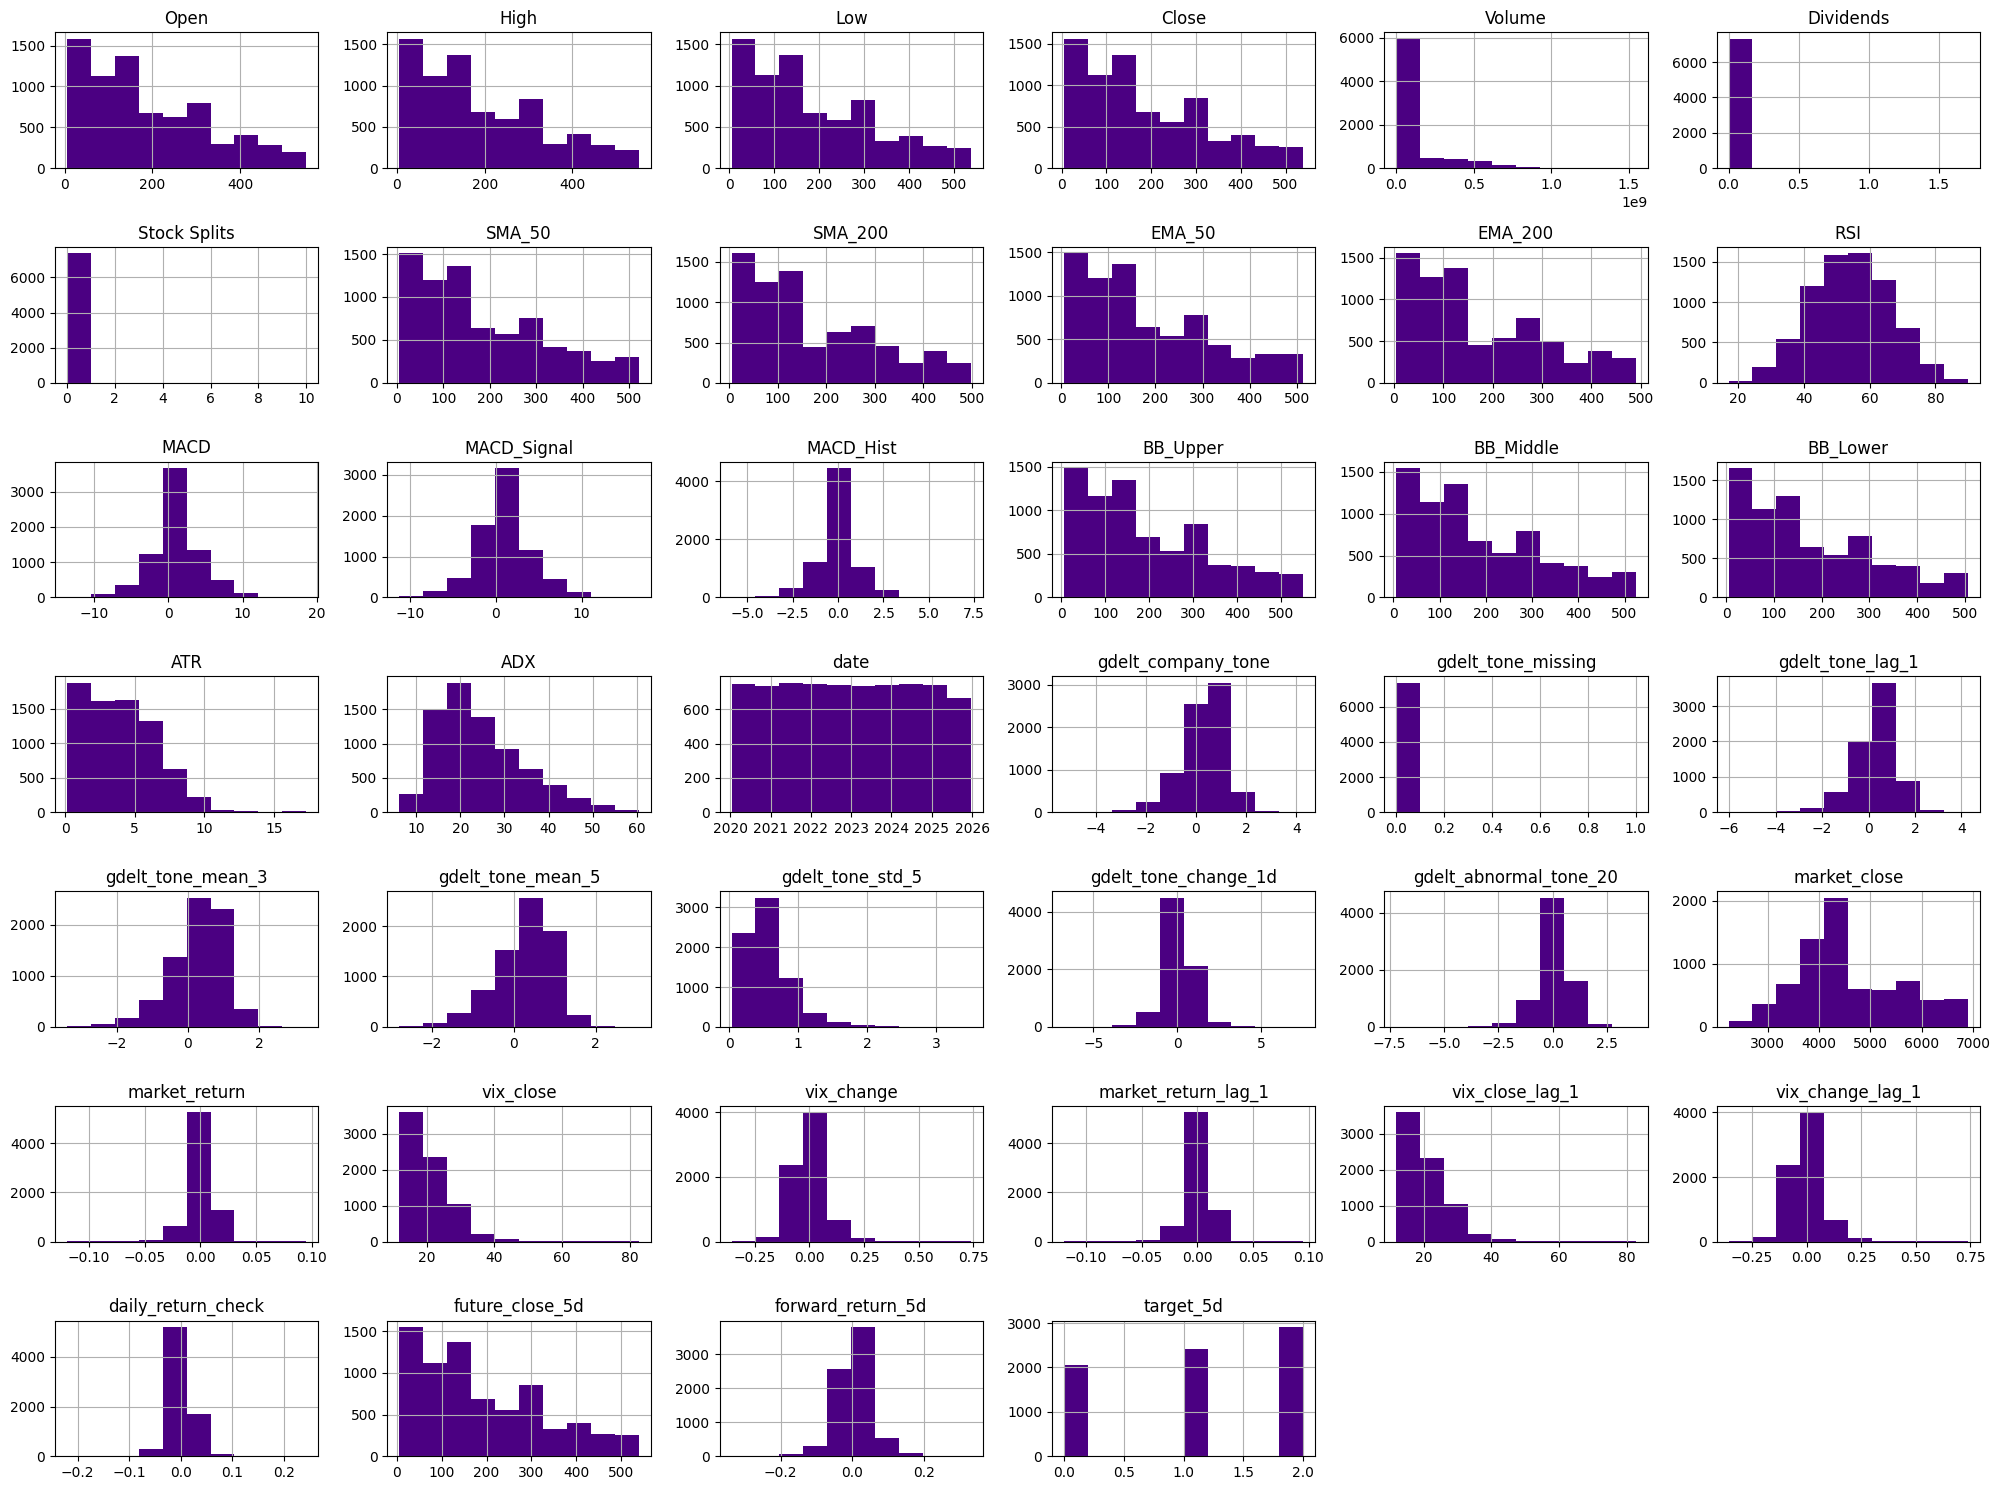

In [3]:
data_df.hist(figsize=(20,15), bins=10, color='indigo')
plt.tight_layout()
plt.show()

## Handle GDELT Tone Missing Values

The missing-tone indicator is retained so that missing GDELT information remains distinguishable from an observed neutral tone. The tone value itself is filled with zero so that the model inputs contain finite numeric values.

In [4]:
# ==========================================================
# Handle Missing GDELT Tone
# ==========================================================

data_df["gdelt_tone_missing"] = (
    data_df["gdelt_company_tone"].isna().astype(int)
)

data_df["gdelt_company_tone"] = (
    data_df["gdelt_company_tone"].fillna(0)
)

print("Remaining missing values:")

missing = (
    data_df.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing[missing > 0].to_frame("Missing Count")
)


Remaining missing values:


,Missing Count


In [5]:
# ==========================================================
# Feature Selection
# ==========================================================

TARGET = "target_5d"

DROP_COLUMNS = [
    # Identifiers
    "ticker",
    "date",

    # Future information / data leakage
    "future_close_5d",
    "forward_return_5d",

    # Target variables
    "movement_5d",
    "target_5d",

    # Low-information features
    "Dividends",
    "Stock Splits"
]

FEATURE_COLUMNS = [
    column
    for column in data_df.columns
    if column not in DROP_COLUMNS
]

print("=" * 60)
print("Feature Selection")
print("=" * 60)

print(f"Total Columns      : {data_df.shape[1]}")
print(f"Dropped Columns    : {len(DROP_COLUMNS)}")
print(f"Predictor Features : {len(FEATURE_COLUMNS)}")

print("\nPredictor Features")
print(FEATURE_COLUMNS)


Feature Selection
Total Columns      : 42
Dropped Columns    : 8
Predictor Features : 34

Predictor Features
['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_50', 'SMA_200', 'EMA_50', 'EMA_200', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'ATR', 'ADX', 'gdelt_company_tone', 'gdelt_tone_missing', 'gdelt_tone_lag_1', 'gdelt_tone_mean_3', 'gdelt_tone_mean_5', 'gdelt_tone_std_5', 'gdelt_tone_change_1d', 'gdelt_abnormal_tone_20', 'market_close', 'market_return', 'vix_close', 'vix_change', 'market_return_lag_1', 'vix_close_lag_1', 'vix_change_lag_1', 'daily_return_check']


## Temporal Train-Test Split

A fixed-year temporal split is used for every stock:

- **Training:** observations before 2025
- **Testing:** observations in 2025

No random train-test split is used because the experiment is designed to respect chronological order.

In [6]:
# ==========================================================
# Experiment Configuration
# ==========================================================

TEST_YEAR = 2025
RANDOM_STATE = 42

stocks = sorted(data_df["ticker"].unique())

print("=" * 60)
print("Experiment Configuration")
print("=" * 60)

print(f"Target Variable : {TARGET}")
print(f"Test Year       : {TEST_YEAR}")
print(f"Random State    : {RANDOM_STATE}")
print(f"Number of Stocks: {len(stocks)}")
print(f"Stocks          : {stocks}")


Experiment Configuration
Target Variable : target_5d
Test Year       : 2025
Random State    : 42
Number of Stocks: 5
Stocks          : ['BRK-B', 'CVX', 'GE', 'MSFT', 'NVDA']


## Prepare Stock-Specific Train/Test Data

This cell prepares the five stocks once and stores their train/test data in `stock_data`.

The model cells below do **not** loop through stocks. Instead, one stock is selected manually and the five model cells are run for that stock.

This keeps the notebook readable while preserving the same experimental setup for every stock.

In [7]:
# ==========================================================
# Prepare Stock-Specific Train/Test Data
# ==========================================================

stock_data = {}

for stock_name in stocks:

    stock_df = data_df[
        data_df["ticker"] == stock_name
    ].copy()

    train_df = stock_df[
        stock_df["date"].dt.year < TEST_YEAR
    ].copy()

    test_df = stock_df[
        stock_df["date"].dt.year == TEST_YEAR
    ].copy()

    x_train_stock = train_df[FEATURE_COLUMNS]
    y_train_stock = train_df[TARGET]

    x_test_stock = test_df[FEATURE_COLUMNS]
    y_test_stock = test_df[TARGET]

    stock_data[stock_name] = {
        "x_train": x_train_stock,
        "y_train": y_train_stock,
        "x_test": x_test_stock,
        "y_test": y_test_stock,
        "test_dates": test_df["date"].values
    }

    print(stock_name)
    print(f"Training samples : {len(train_df)}")
    print(f"Testing samples  : {len(test_df)}")
    print("-" * 40)


BRK-B
Training samples : 1248
Testing samples  : 226
----------------------------------------
CVX
Training samples : 1248
Testing samples  : 226
----------------------------------------
GE
Training samples : 1248
Testing samples  : 226
----------------------------------------
MSFT
Training samples : 1248
Testing samples  : 226
----------------------------------------
NVDA
Training samples : 1248
Testing samples  : 226
----------------------------------------


## Select One Stock

Change only `stock` when moving to the next ticker.

Recommended order:

**BRK-B → CVX → GE → MSFT → NVDA**

Run the **Select One Stock** cell once for the current ticker, then run the five model cells below in order.

The results containers are initialized in a separate cell and are **not reset** when you change stocks.

In [8]:
# ==========================================================
# Initialize Results Containers
# ==========================================================

all_results = []
all_predictions = []

print("Results containers initialized.")


Results containers initialized.


## BRK-B — Stock-Specific Baseline Models

The five models below are trained and evaluated using only this stock's data.

Run these cells in order for the selected stock. Results are appended to the shared `all_results` and `all_predictions` containers.


In [9]:
# ==========================================================
# Select Stock
# ==========================================================

stock = "BRK-B"

x_train = stock_data[stock]["x_train"]
y_train = stock_data[stock]["y_train"]

x_test = stock_data[stock]["x_test"]
y_test = stock_data[stock]["y_test"]

test_dates = stock_data[stock]["test_dates"]

print("=" * 60)
print(f"Selected Stock: {stock}")
print("=" * 60)

print(f"Training samples  : {len(x_train)}")
print(f"Testing samples   : {len(x_test)}")
print(f"Number of features: {x_train.shape[1]}")


Selected Stock: BRK-B
Training samples  : 1248
Testing samples   : 226
Number of features: 34


## Model 1 — Dummy Classifier

The Dummy Classifier provides a simple majority-class baseline. It is not expected to learn relationships between the predictors and the target.

## Model 2 — Random Forest

Random Forest provides a non-linear tree-based baseline. The model uses the original feature scale because tree-based models do not require standardization.

## Model 3 — XGBoost

XGBoost provides a second non-linear tree-based baseline. It also uses the original feature scale.

## Model 4 — Logistic Regression

Logistic Regression is intentionally placed after the tree-based models because its input features must be standardized.

The scaler is fitted only on the training data and then applied to the test data.

## Model 5 — LSTM

LSTM is included as a sequence-based deep-learning baseline.

A **30-trading-day lookback** is used. The scaler is fitted only on the training data. The last 30 scaled training observations are used as historical context for the first 2025 test sequence.

> **GPU note:** GPU acceleration is optional for this relatively small LSTM. If GPU is enabled in Kaggle, training can use it automatically. The model is small enough to run on CPU as well.

> **Reproducibility note:** TensorFlow random seeds are explicitly controlled. Neural-network training can still show small backend/hardware-dependent differences, so LSTM results should be interpreted with appropriate caution.

Dummy Classifier - BRK-B
Accuracy            : 0.5044
Balanced Accuracy   : 0.3333
Precision (Weighted): 0.2544
Recall (Weighted)   : 0.5044
F1 Score (Weighted) : 0.3383
ROC-AUC (OvR)       : 0.5000


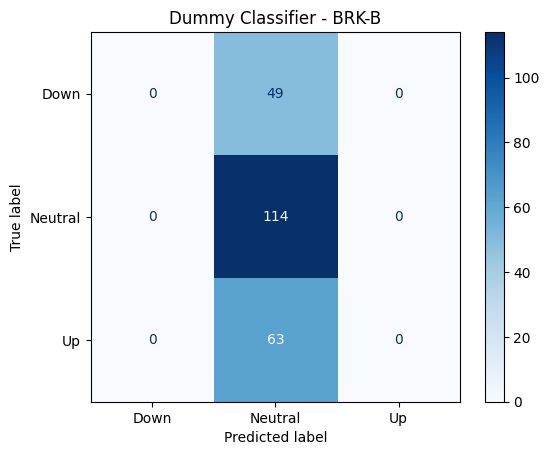


Classification Report
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00        49
     Neutral       0.50      1.00      0.67       114
          Up       0.00      0.00      0.00        63

    accuracy                           0.50       226
   macro avg       0.17      0.33      0.22       226
weighted avg       0.25      0.50      0.34       226



In [10]:
# ==========================================================
# Dummy Classifier
# ==========================================================

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(x_train, y_train)

dummy_pred = dummy_model.predict(x_test)
dummy_prob = dummy_model.predict_proba(x_test)

dummy_accuracy = accuracy_score(y_test, dummy_pred)
dummy_balanced_accuracy = balanced_accuracy_score(y_test, dummy_pred)
dummy_precision = precision_score(
    y_test, dummy_pred,
    average="weighted",
    zero_division=0
)
dummy_recall = recall_score(
    y_test, dummy_pred,
    average="weighted",
    zero_division=0
)
dummy_f1 = f1_score(
    y_test, dummy_pred,
    average="weighted",
    zero_division=0
)
dummy_roc_auc = roc_auc_score(
    y_test,
    dummy_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"Dummy Classifier - {stock}")
print("=" * 60)

print(f"Accuracy            : {dummy_accuracy:.4f}")
print(f"Balanced Accuracy   : {dummy_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {dummy_precision:.4f}")
print(f"Recall (Weighted)   : {dummy_recall:.4f}")
print(f"F1 Score (Weighted) : {dummy_f1:.4f}")
print(f"ROC-AUC (OvR)       : {dummy_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dummy_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"Dummy Classifier - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        dummy_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "Dummy",
    "accuracy": dummy_accuracy,
    "balanced_accuracy": dummy_balanced_accuracy,
    "precision_weighted": dummy_precision,
    "recall_weighted": dummy_recall,
    "f1_weighted": dummy_f1,
    "roc_auc_ovr": dummy_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "Dummy",
        "actual": y_test.values,
        "predicted": dummy_pred,
        "prob_down": dummy_prob[:, 0],
        "prob_neutral": dummy_prob[:, 1],
        "prob_up": dummy_prob[:, 2]
    })
)


Random Forest - BRK-B
Accuracy            : 0.3053
Balanced Accuracy   : 0.3756
Precision (Weighted): 0.4727
Recall (Weighted)   : 0.3053
F1 Score (Weighted) : 0.2529
ROC-AUC (OvR)       : 0.5602


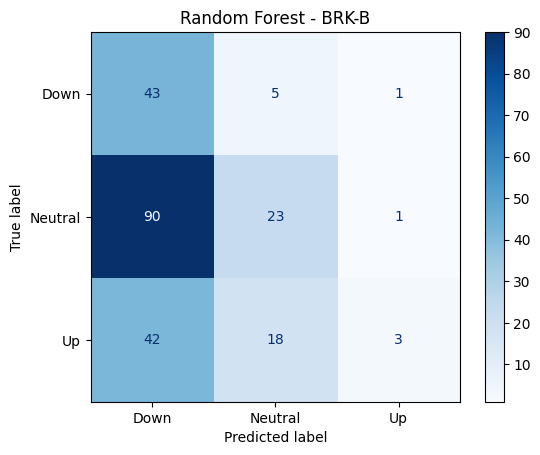


Classification Report
              precision    recall  f1-score   support

        Down       0.25      0.88      0.38        49
     Neutral       0.50      0.20      0.29       114
          Up       0.60      0.05      0.09        63

    accuracy                           0.31       226
   macro avg       0.45      0.38      0.25       226
weighted avg       0.47      0.31      0.25       226



In [11]:
# ==========================================================
# Random Forest
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
rf_prob = rf_model.predict_proba(x_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_balanced_accuracy = balanced_accuracy_score(y_test, rf_pred)
rf_precision = precision_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)
rf_recall = recall_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)
rf_f1 = f1_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)
rf_roc_auc = roc_auc_score(
    y_test,
    rf_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"Random Forest - {stock}")
print("=" * 60)

print(f"Accuracy            : {rf_accuracy:.4f}")
print(f"Balanced Accuracy   : {rf_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {rf_precision:.4f}")
print(f"Recall (Weighted)   : {rf_recall:.4f}")
print(f"F1 Score (Weighted) : {rf_f1:.4f}")
print(f"ROC-AUC (OvR)       : {rf_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"Random Forest - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        rf_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "Random Forest",
    "accuracy": rf_accuracy,
    "balanced_accuracy": rf_balanced_accuracy,
    "precision_weighted": rf_precision,
    "recall_weighted": rf_recall,
    "f1_weighted": rf_f1,
    "roc_auc_ovr": rf_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "Random Forest",
        "actual": y_test.values,
        "predicted": rf_pred,
        "prob_down": rf_prob[:, 0],
        "prob_neutral": rf_prob[:, 1],
        "prob_up": rf_prob[:, 2]
    })
)


XGBoost - BRK-B
Accuracy            : 0.3894
Balanced Accuracy   : 0.4376
Precision (Weighted): 0.5156
Recall (Weighted)   : 0.3894
F1 Score (Weighted) : 0.3666
ROC-AUC (OvR)       : 0.5962


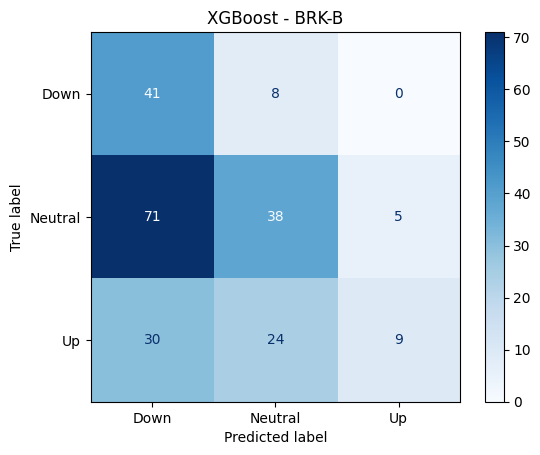


Classification Report
              precision    recall  f1-score   support

        Down       0.29      0.84      0.43        49
     Neutral       0.54      0.33      0.41       114
          Up       0.64      0.14      0.23        63

    accuracy                           0.39       226
   macro avg       0.49      0.44      0.36       226
weighted avg       0.52      0.39      0.37       226



In [12]:
# ==========================================================
# XGBoost
# ==========================================================

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=RANDOM_STATE,
    eval_metric="mlogloss"
)

xgb_model.fit(x_train, y_train)

xgb_pred = xgb_model.predict(x_test)
xgb_prob = xgb_model.predict_proba(x_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_balanced_accuracy = balanced_accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(
    y_test, xgb_pred,
    average="weighted",
    zero_division=0
)
xgb_recall = recall_score(
    y_test, xgb_pred,
    average="weighted",
    zero_division=0
)
xgb_f1 = f1_score(
    y_test, xgb_pred,
    average="weighted",
    zero_division=0
)
xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"XGBoost - {stock}")
print("=" * 60)

print(f"Accuracy            : {xgb_accuracy:.4f}")
print(f"Balanced Accuracy   : {xgb_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {xgb_precision:.4f}")
print(f"Recall (Weighted)   : {xgb_recall:.4f}")
print(f"F1 Score (Weighted) : {xgb_f1:.4f}")
print(f"ROC-AUC (OvR)       : {xgb_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"XGBoost - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        xgb_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "XGBoost",
    "accuracy": xgb_accuracy,
    "balanced_accuracy": xgb_balanced_accuracy,
    "precision_weighted": xgb_precision,
    "recall_weighted": xgb_recall,
    "f1_weighted": xgb_f1,
    "roc_auc_ovr": xgb_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "XGBoost",
        "actual": y_test.values,
        "predicted": xgb_pred,
        "prob_down": xgb_prob[:, 0],
        "prob_neutral": xgb_prob[:, 1],
        "prob_up": xgb_prob[:, 2]
    })
)


Logistic Regression - BRK-B
Accuracy            : 0.3363
Balanced Accuracy   : 0.4080
Precision (Weighted): 0.4815
Recall (Weighted)   : 0.3363
F1 Score (Weighted) : 0.2700
ROC-AUC (OvR)       : 0.5393


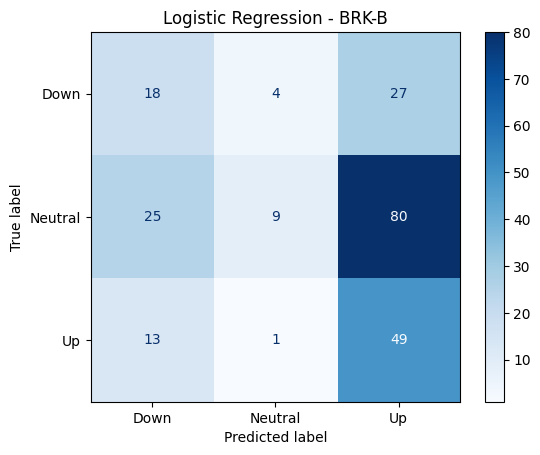


Classification Report
              precision    recall  f1-score   support

        Down       0.32      0.37      0.34        49
     Neutral       0.64      0.08      0.14       114
          Up       0.31      0.78      0.45        63

    accuracy                           0.34       226
   macro avg       0.43      0.41      0.31       226
weighted avg       0.48      0.34      0.27       226



In [13]:
# ==========================================================
# Logistic Regression
# ==========================================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr_model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_model.fit(x_train_scaled, y_train)

lr_pred = lr_model.predict(x_test_scaled)
lr_prob = lr_model.predict_proba(x_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_balanced_accuracy = balanced_accuracy_score(y_test, lr_pred)
lr_precision = precision_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)
lr_recall = recall_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)
lr_f1 = f1_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)
lr_roc_auc = roc_auc_score(
    y_test,
    lr_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"Logistic Regression - {stock}")
print("=" * 60)

print(f"Accuracy            : {lr_accuracy:.4f}")
print(f"Balanced Accuracy   : {lr_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {lr_precision:.4f}")
print(f"Recall (Weighted)   : {lr_recall:.4f}")
print(f"F1 Score (Weighted) : {lr_f1:.4f}")
print(f"ROC-AUC (OvR)       : {lr_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"Logistic Regression - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        lr_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "Logistic Regression",
    "accuracy": lr_accuracy,
    "balanced_accuracy": lr_balanced_accuracy,
    "precision_weighted": lr_precision,
    "recall_weighted": lr_recall,
    "f1_weighted": lr_f1,
    "roc_auc_ovr": lr_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "Logistic Regression",
        "actual": y_test.values,
        "predicted": lr_pred,
        "prob_down": lr_prob[:, 0],
        "prob_neutral": lr_prob[:, 1],
        "prob_up": lr_prob[:, 2]
    })
)


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Training sequence shape: (1218, 30, 34)
Testing sequence shape : (226, 30, 34)


I0000 00:00:1786225740.212430      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786225740.215032      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.2986 - loss: 1.1634 - val_accuracy: 0.3607 - val_loss: 1.1297
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4821 - loss: 1.0411 - val_accuracy: 0.4809 - val_loss: 1.0576
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5121 - loss: 1.0117 - val_accuracy: 0.5027 - val_loss: 1.0576
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5188 - loss: 0.9900 - val_accuracy: 0.4317 - val_loss: 1.0735
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5333 - loss: 0.9681 - val_accuracy: 0.3497 - val_loss: 1.0913
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5469 - loss: 0.9547 - val_accuracy: 0.3388 - val_loss: 1.1285
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5720 - loss: 0.9411 - val_accuracy: 0.3005 - val_loss: 1.1901
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5807 - loss: 0.9207 - val_accuracy: 0.2951 - val_loss

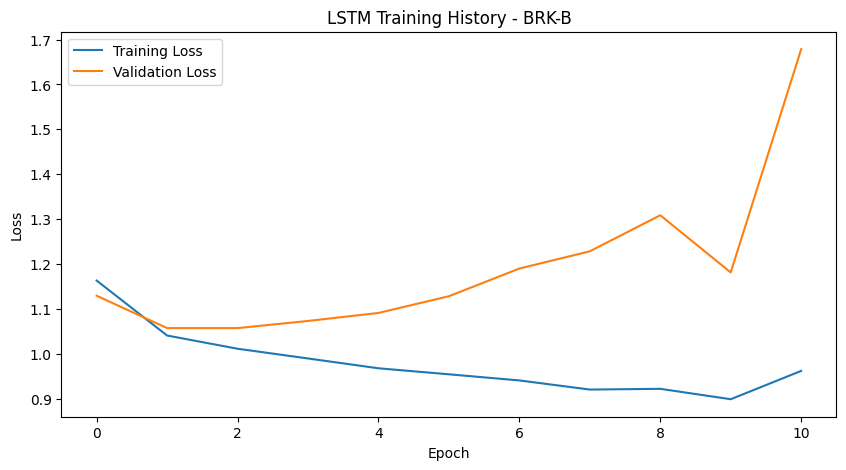

LSTM - BRK-B
Accuracy            : 0.4779
Balanced Accuracy   : 0.3229
Precision (Weighted): 0.3080
Recall (Weighted)   : 0.4779
F1 Score (Weighted) : 0.3484
ROC-AUC (OvR)       : 0.5466


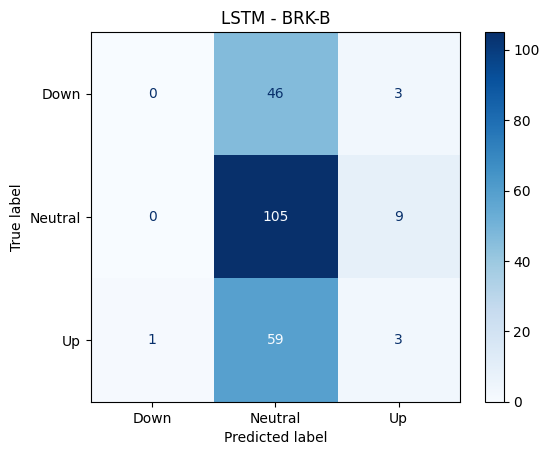


Classification Report
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00        49
     Neutral       0.50      0.92      0.65       114
          Up       0.20      0.05      0.08        63

    accuracy                           0.48       226
   macro avg       0.23      0.32      0.24       226
weighted avg       0.31      0.48      0.35       226



In [14]:
# ==========================================================
# LSTM
# ==========================================================

import tensorflow as tf

tf.keras.utils.set_random_seed(RANDOM_STATE)

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("GPU available:", tf.config.list_physical_devices("GPU"))

# ----------------------------------------------------------
# Scale data using training data only
# ----------------------------------------------------------

lstm_scaler = StandardScaler()

x_train_lstm_scaled = lstm_scaler.fit_transform(x_train)
x_test_lstm_scaled = lstm_scaler.transform(x_test)

x_train_lstm_scaled = pd.DataFrame(
    x_train_lstm_scaled,
    columns=x_train.columns
)

x_test_lstm_scaled = pd.DataFrame(
    x_test_lstm_scaled,
    columns=x_test.columns
)

# ----------------------------------------------------------
# Create sequences
# ----------------------------------------------------------

lookback = 30

x_train_seq = []
y_train_seq = []

for i in range(lookback, len(x_train_lstm_scaled)):

    x_train_seq.append(
        x_train_lstm_scaled.iloc[i-lookback:i].values
    )

    y_train_seq.append(
        y_train.iloc[i]
    )

# Use the final training observations as context for 2025
x_test_context = pd.concat([
    x_train_lstm_scaled.tail(lookback),
    x_test_lstm_scaled
], ignore_index=True)

x_test_seq = []
y_test_seq = []

for i in range(lookback, len(x_test_context)):

    x_test_seq.append(
        x_test_context.iloc[i-lookback:i].values
    )

    y_test_seq.append(
        y_test.iloc[i-lookback]
    )

x_train_seq = np.array(x_train_seq)
y_train_seq = np.array(y_train_seq)

x_test_seq = np.array(x_test_seq)
y_test_seq = np.array(y_test_seq)

print("Training sequence shape:", x_train_seq.shape)
print("Testing sequence shape :", x_test_seq.shape)

# ----------------------------------------------------------
# Build LSTM
# ----------------------------------------------------------

lstm_model = Sequential([
    Input(
        shape=(
            x_train_seq.shape[1],
            x_train_seq.shape[2]
        )
    ),

    LSTM(64),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(3, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ----------------------------------------------------------
# Train LSTM
# ----------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    x_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

# ----------------------------------------------------------
# Training history
# ----------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"LSTM Training History - {stock}")
plt.legend()
plt.show()

# ----------------------------------------------------------
# Evaluate LSTM
# ----------------------------------------------------------

lstm_prob = lstm_model.predict(
    x_test_seq,
    verbose=0
)

lstm_pred = np.argmax(
    lstm_prob,
    axis=1
)

lstm_accuracy = accuracy_score(
    y_test_seq,
    lstm_pred
)

lstm_balanced_accuracy = balanced_accuracy_score(
    y_test_seq,
    lstm_pred
)

lstm_precision = precision_score(
    y_test_seq,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_recall = recall_score(
    y_test_seq,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_f1 = f1_score(
    y_test_seq,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_roc_auc = roc_auc_score(
    y_test_seq,
    lstm_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"LSTM - {stock}")
print("=" * 60)

print(f"Accuracy            : {lstm_accuracy:.4f}")
print(f"Balanced Accuracy   : {lstm_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {lstm_precision:.4f}")
print(f"Recall (Weighted)   : {lstm_recall:.4f}")
print(f"F1 Score (Weighted) : {lstm_f1:.4f}")
print(f"ROC-AUC (OvR)       : {lstm_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test_seq,
    lstm_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"LSTM - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test_seq,
        lstm_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "LSTM",
    "accuracy": lstm_accuracy,
    "balanced_accuracy": lstm_balanced_accuracy,
    "precision_weighted": lstm_precision,
    "recall_weighted": lstm_recall,
    "f1_weighted": lstm_f1,
    "roc_auc_ovr": lstm_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "LSTM",
        "actual": y_test_seq,
        "predicted": lstm_pred,
        "prob_down": lstm_prob[:, 0],
        "prob_neutral": lstm_prob[:, 1],
        "prob_up": lstm_prob[:, 2]
    })
)


## CVX — Stock-Specific Baseline Models

The five models below are trained and evaluated using only this stock's data.

Run these cells in order for the selected stock. Results are appended to the shared `all_results` and `all_predictions` containers.


In [15]:
# ==========================================================
# Select Stock
# ==========================================================

stock = "CVX"

x_train = stock_data[stock]["x_train"]
y_train = stock_data[stock]["y_train"]

x_test = stock_data[stock]["x_test"]
y_test = stock_data[stock]["y_test"]

test_dates = stock_data[stock]["test_dates"]

print("=" * 60)
print(f"Selected Stock: {stock}")
print("=" * 60)

print(f"Training samples  : {len(x_train)}")
print(f"Testing samples   : {len(x_test)}")
print(f"Number of features: {x_train.shape[1]}")


Selected Stock: CVX
Training samples  : 1248
Testing samples   : 226
Number of features: 34


## Model 1 — Dummy Classifier

The Dummy Classifier provides a simple majority-class baseline. It is not expected to learn relationships between the predictors and the target.

## Model 2 — Random Forest

Random Forest provides a non-linear tree-based baseline. The model uses the original feature scale because tree-based models do not require standardization.

## Model 3 — XGBoost

XGBoost provides a second non-linear tree-based baseline. It also uses the original feature scale.

## Model 4 — Logistic Regression

Logistic Regression is intentionally placed after the tree-based models because its input features must be standardized.

The scaler is fitted only on the training data and then applied to the test data.

## Model 5 — LSTM

LSTM is included as a sequence-based deep-learning baseline.

A **30-trading-day lookback** is used. The scaler is fitted only on the training data. The last 30 scaled training observations are used as historical context for the first 2025 test sequence.

> **GPU note:** GPU acceleration is optional for this relatively small LSTM. If GPU is enabled in Kaggle, training can use it automatically. The model is small enough to run on CPU as well.

> **Reproducibility note:** TensorFlow random seeds are explicitly controlled. Neural-network training can still show small backend/hardware-dependent differences, so LSTM results should be interpreted with appropriate caution.

Dummy Classifier - CVX
Accuracy            : 0.3451
Balanced Accuracy   : 0.3333
Precision (Weighted): 0.1191
Recall (Weighted)   : 0.3451
F1 Score (Weighted) : 0.1771
ROC-AUC (OvR)       : 0.5000


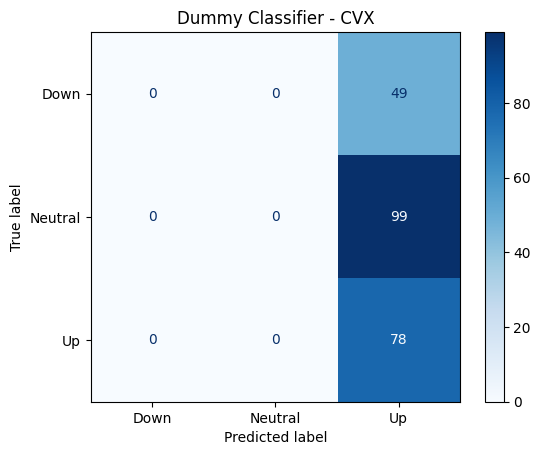


Classification Report
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00        49
     Neutral       0.00      0.00      0.00        99
          Up       0.35      1.00      0.51        78

    accuracy                           0.35       226
   macro avg       0.12      0.33      0.17       226
weighted avg       0.12      0.35      0.18       226



In [16]:
# ==========================================================
# Dummy Classifier
# ==========================================================

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(x_train, y_train)

dummy_pred = dummy_model.predict(x_test)
dummy_prob = dummy_model.predict_proba(x_test)

dummy_accuracy = accuracy_score(y_test, dummy_pred)
dummy_balanced_accuracy = balanced_accuracy_score(y_test, dummy_pred)
dummy_precision = precision_score(
    y_test, dummy_pred,
    average="weighted",
    zero_division=0
)
dummy_recall = recall_score(
    y_test, dummy_pred,
    average="weighted",
    zero_division=0
)
dummy_f1 = f1_score(
    y_test, dummy_pred,
    average="weighted",
    zero_division=0
)
dummy_roc_auc = roc_auc_score(
    y_test,
    dummy_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"Dummy Classifier - {stock}")
print("=" * 60)

print(f"Accuracy            : {dummy_accuracy:.4f}")
print(f"Balanced Accuracy   : {dummy_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {dummy_precision:.4f}")
print(f"Recall (Weighted)   : {dummy_recall:.4f}")
print(f"F1 Score (Weighted) : {dummy_f1:.4f}")
print(f"ROC-AUC (OvR)       : {dummy_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dummy_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"Dummy Classifier - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        dummy_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "Dummy",
    "accuracy": dummy_accuracy,
    "balanced_accuracy": dummy_balanced_accuracy,
    "precision_weighted": dummy_precision,
    "recall_weighted": dummy_recall,
    "f1_weighted": dummy_f1,
    "roc_auc_ovr": dummy_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "Dummy",
        "actual": y_test.values,
        "predicted": dummy_pred,
        "prob_down": dummy_prob[:, 0],
        "prob_neutral": dummy_prob[:, 1],
        "prob_up": dummy_prob[:, 2]
    })
)


Random Forest - CVX
Accuracy            : 0.3363
Balanced Accuracy   : 0.3623
Precision (Weighted): 0.4795
Recall (Weighted)   : 0.3363
F1 Score (Weighted) : 0.3383
ROC-AUC (OvR)       : 0.5633


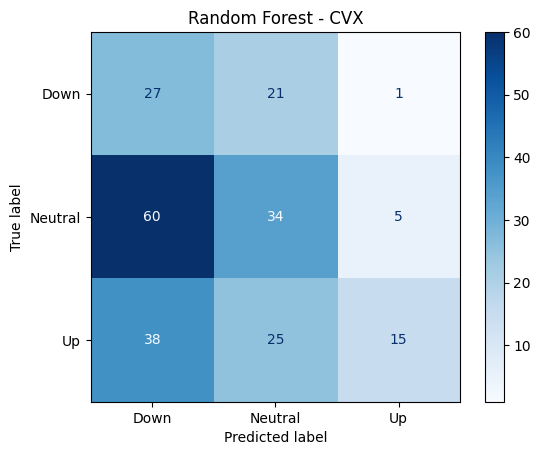


Classification Report
              precision    recall  f1-score   support

        Down       0.22      0.55      0.31        49
     Neutral       0.42      0.34      0.38        99
          Up       0.71      0.19      0.30        78

    accuracy                           0.34       226
   macro avg       0.45      0.36      0.33       226
weighted avg       0.48      0.34      0.34       226



In [17]:
# ==========================================================
# Random Forest
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
rf_prob = rf_model.predict_proba(x_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_balanced_accuracy = balanced_accuracy_score(y_test, rf_pred)
rf_precision = precision_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)
rf_recall = recall_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)
rf_f1 = f1_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)
rf_roc_auc = roc_auc_score(
    y_test,
    rf_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"Random Forest - {stock}")
print("=" * 60)

print(f"Accuracy            : {rf_accuracy:.4f}")
print(f"Balanced Accuracy   : {rf_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {rf_precision:.4f}")
print(f"Recall (Weighted)   : {rf_recall:.4f}")
print(f"F1 Score (Weighted) : {rf_f1:.4f}")
print(f"ROC-AUC (OvR)       : {rf_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"Random Forest - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        rf_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "Random Forest",
    "accuracy": rf_accuracy,
    "balanced_accuracy": rf_balanced_accuracy,
    "precision_weighted": rf_precision,
    "recall_weighted": rf_recall,
    "f1_weighted": rf_f1,
    "roc_auc_ovr": rf_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "Random Forest",
        "actual": y_test.values,
        "predicted": rf_pred,
        "prob_down": rf_prob[:, 0],
        "prob_neutral": rf_prob[:, 1],
        "prob_up": rf_prob[:, 2]
    })
)


XGBoost - CVX
Accuracy            : 0.2920
Balanced Accuracy   : 0.3579
Precision (Weighted): 0.3628
Recall (Weighted)   : 0.2920
F1 Score (Weighted) : 0.2665
ROC-AUC (OvR)       : 0.5310


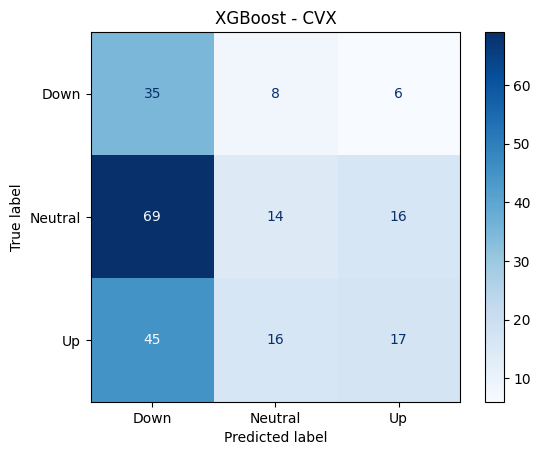


Classification Report
              precision    recall  f1-score   support

        Down       0.23      0.71      0.35        49
     Neutral       0.37      0.14      0.20        99
          Up       0.44      0.22      0.29        78

    accuracy                           0.29       226
   macro avg       0.35      0.36      0.28       226
weighted avg       0.36      0.29      0.27       226



In [18]:
# ==========================================================
# XGBoost
# ==========================================================

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=RANDOM_STATE,
    eval_metric="mlogloss"
)

xgb_model.fit(x_train, y_train)

xgb_pred = xgb_model.predict(x_test)
xgb_prob = xgb_model.predict_proba(x_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_balanced_accuracy = balanced_accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(
    y_test, xgb_pred,
    average="weighted",
    zero_division=0
)
xgb_recall = recall_score(
    y_test, xgb_pred,
    average="weighted",
    zero_division=0
)
xgb_f1 = f1_score(
    y_test, xgb_pred,
    average="weighted",
    zero_division=0
)
xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"XGBoost - {stock}")
print("=" * 60)

print(f"Accuracy            : {xgb_accuracy:.4f}")
print(f"Balanced Accuracy   : {xgb_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {xgb_precision:.4f}")
print(f"Recall (Weighted)   : {xgb_recall:.4f}")
print(f"F1 Score (Weighted) : {xgb_f1:.4f}")
print(f"ROC-AUC (OvR)       : {xgb_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"XGBoost - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        xgb_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "XGBoost",
    "accuracy": xgb_accuracy,
    "balanced_accuracy": xgb_balanced_accuracy,
    "precision_weighted": xgb_precision,
    "recall_weighted": xgb_recall,
    "f1_weighted": xgb_f1,
    "roc_auc_ovr": xgb_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "XGBoost",
        "actual": y_test.values,
        "predicted": xgb_pred,
        "prob_down": xgb_prob[:, 0],
        "prob_neutral": xgb_prob[:, 1],
        "prob_up": xgb_prob[:, 2]
    })
)


Logistic Regression - CVX
Accuracy            : 0.3761
Balanced Accuracy   : 0.3397
Precision (Weighted): 0.3203
Recall (Weighted)   : 0.3761
F1 Score (Weighted) : 0.3109
ROC-AUC (OvR)       : 0.5485


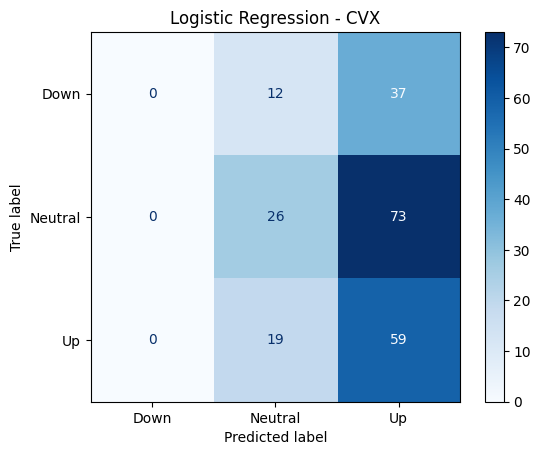


Classification Report
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00        49
     Neutral       0.46      0.26      0.33        99
          Up       0.35      0.76      0.48        78

    accuracy                           0.38       226
   macro avg       0.27      0.34      0.27       226
weighted avg       0.32      0.38      0.31       226



In [19]:
# ==========================================================
# Logistic Regression
# ==========================================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr_model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_model.fit(x_train_scaled, y_train)

lr_pred = lr_model.predict(x_test_scaled)
lr_prob = lr_model.predict_proba(x_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_balanced_accuracy = balanced_accuracy_score(y_test, lr_pred)
lr_precision = precision_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)
lr_recall = recall_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)
lr_f1 = f1_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)
lr_roc_auc = roc_auc_score(
    y_test,
    lr_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"Logistic Regression - {stock}")
print("=" * 60)

print(f"Accuracy            : {lr_accuracy:.4f}")
print(f"Balanced Accuracy   : {lr_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {lr_precision:.4f}")
print(f"Recall (Weighted)   : {lr_recall:.4f}")
print(f"F1 Score (Weighted) : {lr_f1:.4f}")
print(f"ROC-AUC (OvR)       : {lr_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"Logistic Regression - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        lr_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "Logistic Regression",
    "accuracy": lr_accuracy,
    "balanced_accuracy": lr_balanced_accuracy,
    "precision_weighted": lr_precision,
    "recall_weighted": lr_recall,
    "f1_weighted": lr_f1,
    "roc_auc_ovr": lr_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "Logistic Regression",
        "actual": y_test.values,
        "predicted": lr_pred,
        "prob_down": lr_prob[:, 0],
        "prob_neutral": lr_prob[:, 1],
        "prob_up": lr_prob[:, 2]
    })
)


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Training sequence shape: (1218, 30, 34)
Testing sequence shape : (226, 30, 34)
Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3014 - loss: 1.1534 - val_accuracy: 0.3333 - val_loss: 1.1090
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4213 - loss: 1.0656 - val_accuracy: 0.3989 - val_loss: 1.0907
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4802 - loss: 1.0417 - val_accuracy: 0.4153 - val_loss: 1.0772
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4899 - loss: 1.0192 - val_accuracy: 0.3989 - val_loss: 1.0759
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5111 - loss: 1.0007 - val_accuracy: 0.3497 - val_loss: 1.0678
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5256 - loss: 0.9833 - val_accuracy: 0.4098 - val_loss: 1.0569
Epoch 7/50
33/33

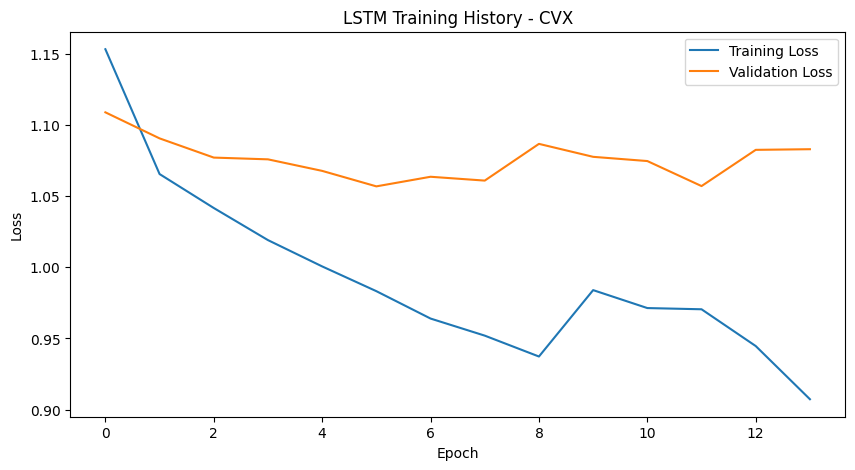

LSTM - CVX
Accuracy            : 0.4071
Balanced Accuracy   : 0.3705
Precision (Weighted): 0.3324
Recall (Weighted)   : 0.4071
F1 Score (Weighted) : 0.3285
ROC-AUC (OvR)       : 0.5444


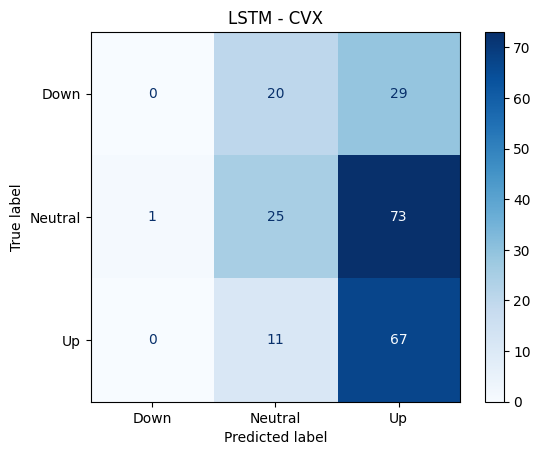


Classification Report
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00        49
     Neutral       0.45      0.25      0.32        99
          Up       0.40      0.86      0.54        78

    accuracy                           0.41       226
   macro avg       0.28      0.37      0.29       226
weighted avg       0.33      0.41      0.33       226



In [20]:
# ==========================================================
# LSTM
# ==========================================================

import tensorflow as tf

tf.keras.utils.set_random_seed(RANDOM_STATE)

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("GPU available:", tf.config.list_physical_devices("GPU"))

# ----------------------------------------------------------
# Scale data using training data only
# ----------------------------------------------------------

lstm_scaler = StandardScaler()

x_train_lstm_scaled = lstm_scaler.fit_transform(x_train)
x_test_lstm_scaled = lstm_scaler.transform(x_test)

x_train_lstm_scaled = pd.DataFrame(
    x_train_lstm_scaled,
    columns=x_train.columns
)

x_test_lstm_scaled = pd.DataFrame(
    x_test_lstm_scaled,
    columns=x_test.columns
)

# ----------------------------------------------------------
# Create sequences
# ----------------------------------------------------------

lookback = 30

x_train_seq = []
y_train_seq = []

for i in range(lookback, len(x_train_lstm_scaled)):

    x_train_seq.append(
        x_train_lstm_scaled.iloc[i-lookback:i].values
    )

    y_train_seq.append(
        y_train.iloc[i]
    )

# Use the final training observations as context for 2025
x_test_context = pd.concat([
    x_train_lstm_scaled.tail(lookback),
    x_test_lstm_scaled
], ignore_index=True)

x_test_seq = []
y_test_seq = []

for i in range(lookback, len(x_test_context)):

    x_test_seq.append(
        x_test_context.iloc[i-lookback:i].values
    )

    y_test_seq.append(
        y_test.iloc[i-lookback]
    )

x_train_seq = np.array(x_train_seq)
y_train_seq = np.array(y_train_seq)

x_test_seq = np.array(x_test_seq)
y_test_seq = np.array(y_test_seq)

print("Training sequence shape:", x_train_seq.shape)
print("Testing sequence shape :", x_test_seq.shape)

# ----------------------------------------------------------
# Build LSTM
# ----------------------------------------------------------

lstm_model = Sequential([
    Input(
        shape=(
            x_train_seq.shape[1],
            x_train_seq.shape[2]
        )
    ),

    LSTM(64),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(3, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ----------------------------------------------------------
# Train LSTM
# ----------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    x_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

# ----------------------------------------------------------
# Training history
# ----------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"LSTM Training History - {stock}")
plt.legend()
plt.show()

# ----------------------------------------------------------
# Evaluate LSTM
# ----------------------------------------------------------

lstm_prob = lstm_model.predict(
    x_test_seq,
    verbose=0
)

lstm_pred = np.argmax(
    lstm_prob,
    axis=1
)

lstm_accuracy = accuracy_score(
    y_test_seq,
    lstm_pred
)

lstm_balanced_accuracy = balanced_accuracy_score(
    y_test_seq,
    lstm_pred
)

lstm_precision = precision_score(
    y_test_seq,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_recall = recall_score(
    y_test_seq,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_f1 = f1_score(
    y_test_seq,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_roc_auc = roc_auc_score(
    y_test_seq,
    lstm_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"LSTM - {stock}")
print("=" * 60)

print(f"Accuracy            : {lstm_accuracy:.4f}")
print(f"Balanced Accuracy   : {lstm_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {lstm_precision:.4f}")
print(f"Recall (Weighted)   : {lstm_recall:.4f}")
print(f"F1 Score (Weighted) : {lstm_f1:.4f}")
print(f"ROC-AUC (OvR)       : {lstm_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test_seq,
    lstm_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"LSTM - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test_seq,
        lstm_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "LSTM",
    "accuracy": lstm_accuracy,
    "balanced_accuracy": lstm_balanced_accuracy,
    "precision_weighted": lstm_precision,
    "recall_weighted": lstm_recall,
    "f1_weighted": lstm_f1,
    "roc_auc_ovr": lstm_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "LSTM",
        "actual": y_test_seq,
        "predicted": lstm_pred,
        "prob_down": lstm_prob[:, 0],
        "prob_neutral": lstm_prob[:, 1],
        "prob_up": lstm_prob[:, 2]
    })
)


## GE — Stock-Specific Baseline Models

The five models below are trained and evaluated using only this stock's data.

Run these cells in order for the selected stock. Results are appended to the shared `all_results` and `all_predictions` containers.


In [21]:
# ==========================================================
# Select Stock
# ==========================================================

stock = "GE"

x_train = stock_data[stock]["x_train"]
y_train = stock_data[stock]["y_train"]

x_test = stock_data[stock]["x_test"]
y_test = stock_data[stock]["y_test"]

test_dates = stock_data[stock]["test_dates"]

print("=" * 60)
print(f"Selected Stock: {stock}")
print("=" * 60)

print(f"Training samples  : {len(x_train)}")
print(f"Testing samples   : {len(x_test)}")
print(f"Number of features: {x_train.shape[1]}")


Selected Stock: GE
Training samples  : 1248
Testing samples   : 226
Number of features: 34


## Model 1 — Dummy Classifier

The Dummy Classifier provides a simple majority-class baseline. It is not expected to learn relationships between the predictors and the target.

## Model 2 — Random Forest

Random Forest provides a non-linear tree-based baseline. The model uses the original feature scale because tree-based models do not require standardization.

## Model 3 — XGBoost

XGBoost provides a second non-linear tree-based baseline. It also uses the original feature scale.

## Model 4 — Logistic Regression

Logistic Regression is intentionally placed after the tree-based models because its input features must be standardized.

The scaler is fitted only on the training data and then applied to the test data.

## Model 5 — LSTM

LSTM is included as a sequence-based deep-learning baseline.

A **30-trading-day lookback** is used. The scaler is fitted only on the training data. The last 30 scaled training observations are used as historical context for the first 2025 test sequence.

> **GPU note:** GPU acceleration is optional for this relatively small LSTM. If GPU is enabled in Kaggle, training can use it automatically. The model is small enough to run on CPU as well.

> **Reproducibility note:** TensorFlow random seeds are explicitly controlled. Neural-network training can still show small backend/hardware-dependent differences, so LSTM results should be interpreted with appropriate caution.

Dummy Classifier - GE
Accuracy            : 0.4867
Balanced Accuracy   : 0.3333
Precision (Weighted): 0.2369
Recall (Weighted)   : 0.4867
F1 Score (Weighted) : 0.3187
ROC-AUC (OvR)       : 0.5000


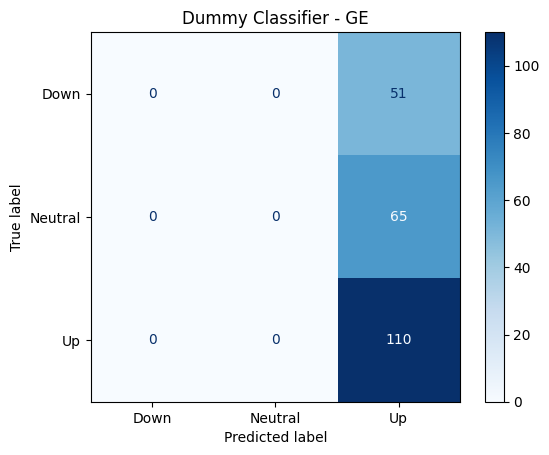


Classification Report
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00        51
     Neutral       0.00      0.00      0.00        65
          Up       0.49      1.00      0.65       110

    accuracy                           0.49       226
   macro avg       0.16      0.33      0.22       226
weighted avg       0.24      0.49      0.32       226



In [22]:
# ==========================================================
# Dummy Classifier
# ==========================================================

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(x_train, y_train)

dummy_pred = dummy_model.predict(x_test)
dummy_prob = dummy_model.predict_proba(x_test)

dummy_accuracy = accuracy_score(y_test, dummy_pred)
dummy_balanced_accuracy = balanced_accuracy_score(y_test, dummy_pred)
dummy_precision = precision_score(
    y_test, dummy_pred,
    average="weighted",
    zero_division=0
)
dummy_recall = recall_score(
    y_test, dummy_pred,
    average="weighted",
    zero_division=0
)
dummy_f1 = f1_score(
    y_test, dummy_pred,
    average="weighted",
    zero_division=0
)
dummy_roc_auc = roc_auc_score(
    y_test,
    dummy_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"Dummy Classifier - {stock}")
print("=" * 60)

print(f"Accuracy            : {dummy_accuracy:.4f}")
print(f"Balanced Accuracy   : {dummy_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {dummy_precision:.4f}")
print(f"Recall (Weighted)   : {dummy_recall:.4f}")
print(f"F1 Score (Weighted) : {dummy_f1:.4f}")
print(f"ROC-AUC (OvR)       : {dummy_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dummy_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"Dummy Classifier - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        dummy_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "Dummy",
    "accuracy": dummy_accuracy,
    "balanced_accuracy": dummy_balanced_accuracy,
    "precision_weighted": dummy_precision,
    "recall_weighted": dummy_recall,
    "f1_weighted": dummy_f1,
    "roc_auc_ovr": dummy_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "Dummy",
        "actual": y_test.values,
        "predicted": dummy_pred,
        "prob_down": dummy_prob[:, 0],
        "prob_neutral": dummy_prob[:, 1],
        "prob_up": dummy_prob[:, 2]
    })
)


Random Forest - GE
Accuracy            : 0.3274
Balanced Accuracy   : 0.3960
Precision (Weighted): 0.4778
Recall (Weighted)   : 0.3274
F1 Score (Weighted) : 0.2668
ROC-AUC (OvR)       : 0.5797


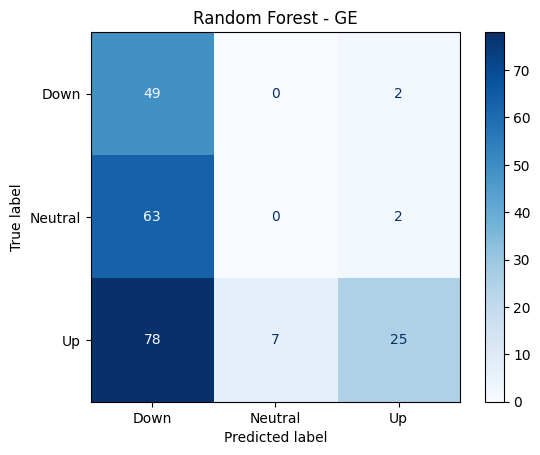


Classification Report
              precision    recall  f1-score   support

        Down       0.26      0.96      0.41        51
     Neutral       0.00      0.00      0.00        65
          Up       0.86      0.23      0.36       110

    accuracy                           0.33       226
   macro avg       0.37      0.40      0.26       226
weighted avg       0.48      0.33      0.27       226



In [23]:
# ==========================================================
# Random Forest
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
rf_prob = rf_model.predict_proba(x_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_balanced_accuracy = balanced_accuracy_score(y_test, rf_pred)
rf_precision = precision_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)
rf_recall = recall_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)
rf_f1 = f1_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)
rf_roc_auc = roc_auc_score(
    y_test,
    rf_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"Random Forest - {stock}")
print("=" * 60)

print(f"Accuracy            : {rf_accuracy:.4f}")
print(f"Balanced Accuracy   : {rf_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {rf_precision:.4f}")
print(f"Recall (Weighted)   : {rf_recall:.4f}")
print(f"F1 Score (Weighted) : {rf_f1:.4f}")
print(f"ROC-AUC (OvR)       : {rf_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"Random Forest - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        rf_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "Random Forest",
    "accuracy": rf_accuracy,
    "balanced_accuracy": rf_balanced_accuracy,
    "precision_weighted": rf_precision,
    "recall_weighted": rf_recall,
    "f1_weighted": rf_f1,
    "roc_auc_ovr": rf_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "Random Forest",
        "actual": y_test.values,
        "predicted": rf_pred,
        "prob_down": rf_prob[:, 0],
        "prob_neutral": rf_prob[:, 1],
        "prob_up": rf_prob[:, 2]
    })
)


XGBoost - GE
Accuracy            : 0.3894
Balanced Accuracy   : 0.4482
Precision (Weighted): 0.5742
Recall (Weighted)   : 0.3894
F1 Score (Weighted) : 0.3764
ROC-AUC (OvR)       : 0.5828


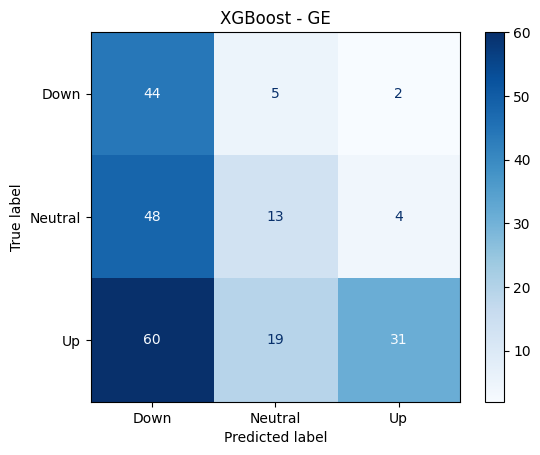


Classification Report
              precision    recall  f1-score   support

        Down       0.29      0.86      0.43        51
     Neutral       0.35      0.20      0.25        65
          Up       0.84      0.28      0.42       110

    accuracy                           0.39       226
   macro avg       0.49      0.45      0.37       226
weighted avg       0.57      0.39      0.38       226



In [24]:
# ==========================================================
# XGBoost
# ==========================================================

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=RANDOM_STATE,
    eval_metric="mlogloss"
)

xgb_model.fit(x_train, y_train)

xgb_pred = xgb_model.predict(x_test)
xgb_prob = xgb_model.predict_proba(x_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_balanced_accuracy = balanced_accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(
    y_test, xgb_pred,
    average="weighted",
    zero_division=0
)
xgb_recall = recall_score(
    y_test, xgb_pred,
    average="weighted",
    zero_division=0
)
xgb_f1 = f1_score(
    y_test, xgb_pred,
    average="weighted",
    zero_division=0
)
xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"XGBoost - {stock}")
print("=" * 60)

print(f"Accuracy            : {xgb_accuracy:.4f}")
print(f"Balanced Accuracy   : {xgb_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {xgb_precision:.4f}")
print(f"Recall (Weighted)   : {xgb_recall:.4f}")
print(f"F1 Score (Weighted) : {xgb_f1:.4f}")
print(f"ROC-AUC (OvR)       : {xgb_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"XGBoost - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        xgb_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "XGBoost",
    "accuracy": xgb_accuracy,
    "balanced_accuracy": xgb_balanced_accuracy,
    "precision_weighted": xgb_precision,
    "recall_weighted": xgb_recall,
    "f1_weighted": xgb_f1,
    "roc_auc_ovr": xgb_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "XGBoost",
        "actual": y_test.values,
        "predicted": xgb_pred,
        "prob_down": xgb_prob[:, 0],
        "prob_neutral": xgb_prob[:, 1],
        "prob_up": xgb_prob[:, 2]
    })
)


Logistic Regression - GE
Accuracy            : 0.3717
Balanced Accuracy   : 0.2987
Precision (Weighted): 0.3329
Recall (Weighted)   : 0.3717
F1 Score (Weighted) : 0.3133
ROC-AUC (OvR)       : 0.4880


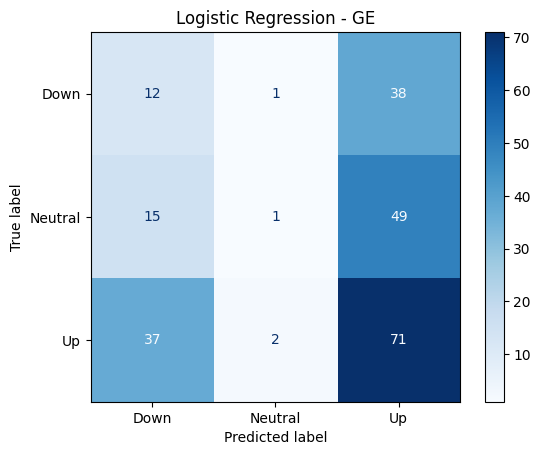


Classification Report
              precision    recall  f1-score   support

        Down       0.19      0.24      0.21        51
     Neutral       0.25      0.02      0.03        65
          Up       0.45      0.65      0.53       110

    accuracy                           0.37       226
   macro avg       0.30      0.30      0.26       226
weighted avg       0.33      0.37      0.31       226



In [25]:
# ==========================================================
# Logistic Regression
# ==========================================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr_model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_model.fit(x_train_scaled, y_train)

lr_pred = lr_model.predict(x_test_scaled)
lr_prob = lr_model.predict_proba(x_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_balanced_accuracy = balanced_accuracy_score(y_test, lr_pred)
lr_precision = precision_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)
lr_recall = recall_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)
lr_f1 = f1_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)
lr_roc_auc = roc_auc_score(
    y_test,
    lr_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"Logistic Regression - {stock}")
print("=" * 60)

print(f"Accuracy            : {lr_accuracy:.4f}")
print(f"Balanced Accuracy   : {lr_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {lr_precision:.4f}")
print(f"Recall (Weighted)   : {lr_recall:.4f}")
print(f"F1 Score (Weighted) : {lr_f1:.4f}")
print(f"ROC-AUC (OvR)       : {lr_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"Logistic Regression - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        lr_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "Logistic Regression",
    "accuracy": lr_accuracy,
    "balanced_accuracy": lr_balanced_accuracy,
    "precision_weighted": lr_precision,
    "recall_weighted": lr_recall,
    "f1_weighted": lr_f1,
    "roc_auc_ovr": lr_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "Logistic Regression",
        "actual": y_test.values,
        "predicted": lr_pred,
        "prob_down": lr_prob[:, 0],
        "prob_neutral": lr_prob[:, 1],
        "prob_up": lr_prob[:, 2]
    })
)


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Training sequence shape: (1218, 30, 34)
Testing sequence shape : (226, 30, 34)
Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3459 - loss: 1.1292 - val_accuracy: 0.3880 - val_loss: 1.1206
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4280 - loss: 1.0428 - val_accuracy: 0.3934 - val_loss: 1.1579
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4502 - loss: 1.0176 - val_accuracy: 0.3934 - val_loss: 1.2161
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4802 - loss: 1.0022 - val_accuracy: 0.3934 - val_loss: 1.2597
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5150 - loss: 0.9845 - val_accuracy: 0.3934 - val_loss: 1.2875
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5005 - loss: 0.9750 - val_accuracy: 0.3934 - val_loss: 1.4098
Epoch 7/50
33/33

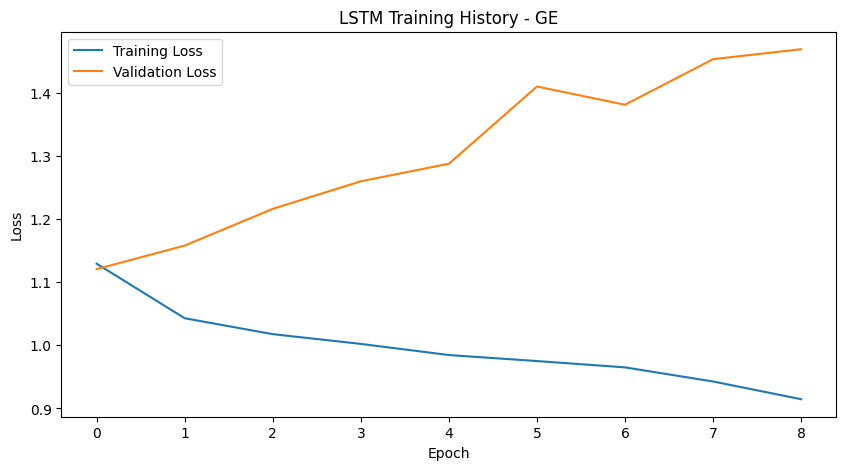

LSTM - GE
Accuracy            : 0.2743
Balanced Accuracy   : 0.3553
Precision (Weighted): 0.2852
Recall (Weighted)   : 0.2743
F1 Score (Weighted) : 0.2104
ROC-AUC (OvR)       : 0.4094


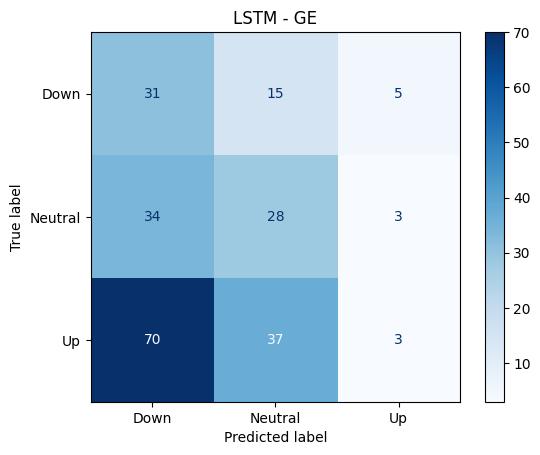


Classification Report
              precision    recall  f1-score   support

        Down       0.23      0.61      0.33        51
     Neutral       0.35      0.43      0.39        65
          Up       0.27      0.03      0.05       110

    accuracy                           0.27       226
   macro avg       0.28      0.36      0.26       226
weighted avg       0.29      0.27      0.21       226



In [26]:
# ==========================================================
# LSTM
# ==========================================================

import tensorflow as tf

tf.keras.utils.set_random_seed(RANDOM_STATE)

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("GPU available:", tf.config.list_physical_devices("GPU"))

# ----------------------------------------------------------
# Scale data using training data only
# ----------------------------------------------------------

lstm_scaler = StandardScaler()

x_train_lstm_scaled = lstm_scaler.fit_transform(x_train)
x_test_lstm_scaled = lstm_scaler.transform(x_test)

x_train_lstm_scaled = pd.DataFrame(
    x_train_lstm_scaled,
    columns=x_train.columns
)

x_test_lstm_scaled = pd.DataFrame(
    x_test_lstm_scaled,
    columns=x_test.columns
)

# ----------------------------------------------------------
# Create sequences
# ----------------------------------------------------------

lookback = 30

x_train_seq = []
y_train_seq = []

for i in range(lookback, len(x_train_lstm_scaled)):

    x_train_seq.append(
        x_train_lstm_scaled.iloc[i-lookback:i].values
    )

    y_train_seq.append(
        y_train.iloc[i]
    )

# Use the final training observations as context for 2025
x_test_context = pd.concat([
    x_train_lstm_scaled.tail(lookback),
    x_test_lstm_scaled
], ignore_index=True)

x_test_seq = []
y_test_seq = []

for i in range(lookback, len(x_test_context)):

    x_test_seq.append(
        x_test_context.iloc[i-lookback:i].values
    )

    y_test_seq.append(
        y_test.iloc[i-lookback]
    )

x_train_seq = np.array(x_train_seq)
y_train_seq = np.array(y_train_seq)

x_test_seq = np.array(x_test_seq)
y_test_seq = np.array(y_test_seq)

print("Training sequence shape:", x_train_seq.shape)
print("Testing sequence shape :", x_test_seq.shape)

# ----------------------------------------------------------
# Build LSTM
# ----------------------------------------------------------

lstm_model = Sequential([
    Input(
        shape=(
            x_train_seq.shape[1],
            x_train_seq.shape[2]
        )
    ),

    LSTM(64),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(3, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ----------------------------------------------------------
# Train LSTM
# ----------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    x_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

# ----------------------------------------------------------
# Training history
# ----------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"LSTM Training History - {stock}")
plt.legend()
plt.show()

# ----------------------------------------------------------
# Evaluate LSTM
# ----------------------------------------------------------

lstm_prob = lstm_model.predict(
    x_test_seq,
    verbose=0
)

lstm_pred = np.argmax(
    lstm_prob,
    axis=1
)

lstm_accuracy = accuracy_score(
    y_test_seq,
    lstm_pred
)

lstm_balanced_accuracy = balanced_accuracy_score(
    y_test_seq,
    lstm_pred
)

lstm_precision = precision_score(
    y_test_seq,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_recall = recall_score(
    y_test_seq,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_f1 = f1_score(
    y_test_seq,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_roc_auc = roc_auc_score(
    y_test_seq,
    lstm_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"LSTM - {stock}")
print("=" * 60)

print(f"Accuracy            : {lstm_accuracy:.4f}")
print(f"Balanced Accuracy   : {lstm_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {lstm_precision:.4f}")
print(f"Recall (Weighted)   : {lstm_recall:.4f}")
print(f"F1 Score (Weighted) : {lstm_f1:.4f}")
print(f"ROC-AUC (OvR)       : {lstm_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test_seq,
    lstm_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"LSTM - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test_seq,
        lstm_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "LSTM",
    "accuracy": lstm_accuracy,
    "balanced_accuracy": lstm_balanced_accuracy,
    "precision_weighted": lstm_precision,
    "recall_weighted": lstm_recall,
    "f1_weighted": lstm_f1,
    "roc_auc_ovr": lstm_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "LSTM",
        "actual": y_test_seq,
        "predicted": lstm_pred,
        "prob_down": lstm_prob[:, 0],
        "prob_neutral": lstm_prob[:, 1],
        "prob_up": lstm_prob[:, 2]
    })
)


## MSFT — Stock-Specific Baseline Models

The five models below are trained and evaluated using only this stock's data.

Run these cells in order for the selected stock. Results are appended to the shared `all_results` and `all_predictions` containers.


In [27]:
# ==========================================================
# Select Stock
# ==========================================================

stock = "MSFT"

x_train = stock_data[stock]["x_train"]
y_train = stock_data[stock]["y_train"]

x_test = stock_data[stock]["x_test"]
y_test = stock_data[stock]["y_test"]

test_dates = stock_data[stock]["test_dates"]

print("=" * 60)
print(f"Selected Stock: {stock}")
print("=" * 60)

print(f"Training samples  : {len(x_train)}")
print(f"Testing samples   : {len(x_test)}")
print(f"Number of features: {x_train.shape[1]}")


Selected Stock: MSFT
Training samples  : 1248
Testing samples   : 226
Number of features: 34


## Model 1 — Dummy Classifier

The Dummy Classifier provides a simple majority-class baseline. It is not expected to learn relationships between the predictors and the target.

## Model 2 — Random Forest

Random Forest provides a non-linear tree-based baseline. The model uses the original feature scale because tree-based models do not require standardization.

## Model 3 — XGBoost

XGBoost provides a second non-linear tree-based baseline. It also uses the original feature scale.

## Model 4 — Logistic Regression

Logistic Regression is intentionally placed after the tree-based models because its input features must be standardized.

The scaler is fitted only on the training data and then applied to the test data.

## Model 5 — LSTM

LSTM is included as a sequence-based deep-learning baseline.

A **30-trading-day lookback** is used. The scaler is fitted only on the training data. The last 30 scaled training observations are used as historical context for the first 2025 test sequence.

> **GPU note:** GPU acceleration is optional for this relatively small LSTM. If GPU is enabled in Kaggle, training can use it automatically. The model is small enough to run on CPU as well.

> **Reproducibility note:** TensorFlow random seeds are explicitly controlled. Neural-network training can still show small backend/hardware-dependent differences, so LSTM results should be interpreted with appropriate caution.

Dummy Classifier - MSFT
Accuracy            : 0.3097
Balanced Accuracy   : 0.3333
Precision (Weighted): 0.0959
Recall (Weighted)   : 0.3097
F1 Score (Weighted) : 0.1465
ROC-AUC (OvR)       : 0.5000


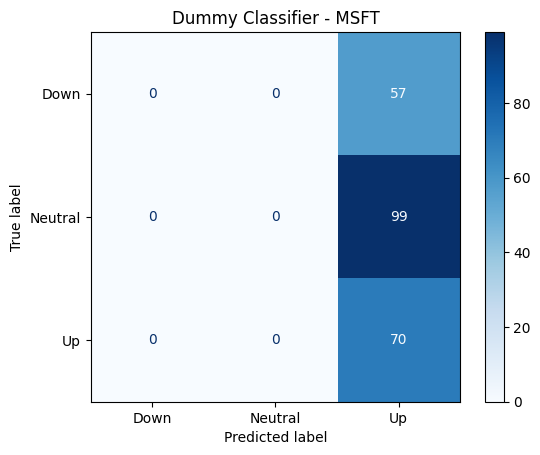


Classification Report
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00        57
     Neutral       0.00      0.00      0.00        99
          Up       0.31      1.00      0.47        70

    accuracy                           0.31       226
   macro avg       0.10      0.33      0.16       226
weighted avg       0.10      0.31      0.15       226



In [28]:
# ==========================================================
# Dummy Classifier
# ==========================================================

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(x_train, y_train)

dummy_pred = dummy_model.predict(x_test)
dummy_prob = dummy_model.predict_proba(x_test)

dummy_accuracy = accuracy_score(y_test, dummy_pred)
dummy_balanced_accuracy = balanced_accuracy_score(y_test, dummy_pred)
dummy_precision = precision_score(
    y_test, dummy_pred,
    average="weighted",
    zero_division=0
)
dummy_recall = recall_score(
    y_test, dummy_pred,
    average="weighted",
    zero_division=0
)
dummy_f1 = f1_score(
    y_test, dummy_pred,
    average="weighted",
    zero_division=0
)
dummy_roc_auc = roc_auc_score(
    y_test,
    dummy_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"Dummy Classifier - {stock}")
print("=" * 60)

print(f"Accuracy            : {dummy_accuracy:.4f}")
print(f"Balanced Accuracy   : {dummy_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {dummy_precision:.4f}")
print(f"Recall (Weighted)   : {dummy_recall:.4f}")
print(f"F1 Score (Weighted) : {dummy_f1:.4f}")
print(f"ROC-AUC (OvR)       : {dummy_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dummy_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"Dummy Classifier - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        dummy_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "Dummy",
    "accuracy": dummy_accuracy,
    "balanced_accuracy": dummy_balanced_accuracy,
    "precision_weighted": dummy_precision,
    "recall_weighted": dummy_recall,
    "f1_weighted": dummy_f1,
    "roc_auc_ovr": dummy_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "Dummy",
        "actual": y_test.values,
        "predicted": dummy_pred,
        "prob_down": dummy_prob[:, 0],
        "prob_neutral": dummy_prob[:, 1],
        "prob_up": dummy_prob[:, 2]
    })
)


Random Forest - MSFT
Accuracy            : 0.3053
Balanced Accuracy   : 0.3233
Precision (Weighted): 0.3800
Recall (Weighted)   : 0.3053
F1 Score (Weighted) : 0.3109
ROC-AUC (OvR)       : 0.5362


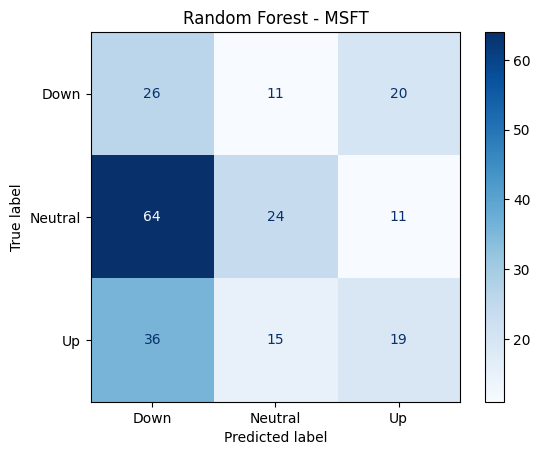


Classification Report
              precision    recall  f1-score   support

        Down       0.21      0.46      0.28        57
     Neutral       0.48      0.24      0.32        99
          Up       0.38      0.27      0.32        70

    accuracy                           0.31       226
   macro avg       0.36      0.32      0.31       226
weighted avg       0.38      0.31      0.31       226



In [29]:
# ==========================================================
# Random Forest
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
rf_prob = rf_model.predict_proba(x_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_balanced_accuracy = balanced_accuracy_score(y_test, rf_pred)
rf_precision = precision_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)
rf_recall = recall_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)
rf_f1 = f1_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)
rf_roc_auc = roc_auc_score(
    y_test,
    rf_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"Random Forest - {stock}")
print("=" * 60)

print(f"Accuracy            : {rf_accuracy:.4f}")
print(f"Balanced Accuracy   : {rf_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {rf_precision:.4f}")
print(f"Recall (Weighted)   : {rf_recall:.4f}")
print(f"F1 Score (Weighted) : {rf_f1:.4f}")
print(f"ROC-AUC (OvR)       : {rf_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"Random Forest - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        rf_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "Random Forest",
    "accuracy": rf_accuracy,
    "balanced_accuracy": rf_balanced_accuracy,
    "precision_weighted": rf_precision,
    "recall_weighted": rf_recall,
    "f1_weighted": rf_f1,
    "roc_auc_ovr": rf_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "Random Forest",
        "actual": y_test.values,
        "predicted": rf_pred,
        "prob_down": rf_prob[:, 0],
        "prob_neutral": rf_prob[:, 1],
        "prob_up": rf_prob[:, 2]
    })
)


XGBoost - MSFT
Accuracy            : 0.2743
Balanced Accuracy   : 0.3089
Precision (Weighted): 0.3305
Recall (Weighted)   : 0.2743
F1 Score (Weighted) : 0.2590
ROC-AUC (OvR)       : 0.5018


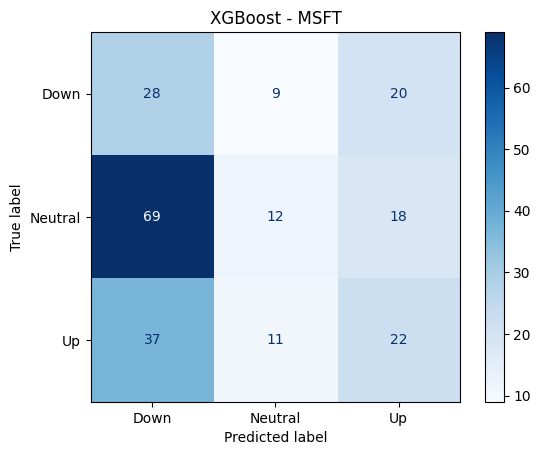


Classification Report
              precision    recall  f1-score   support

        Down       0.21      0.49      0.29        57
     Neutral       0.38      0.12      0.18        99
          Up       0.37      0.31      0.34        70

    accuracy                           0.27       226
   macro avg       0.32      0.31      0.27       226
weighted avg       0.33      0.27      0.26       226



In [30]:
# ==========================================================
# XGBoost
# ==========================================================

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=RANDOM_STATE,
    eval_metric="mlogloss"
)

xgb_model.fit(x_train, y_train)

xgb_pred = xgb_model.predict(x_test)
xgb_prob = xgb_model.predict_proba(x_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_balanced_accuracy = balanced_accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(
    y_test, xgb_pred,
    average="weighted",
    zero_division=0
)
xgb_recall = recall_score(
    y_test, xgb_pred,
    average="weighted",
    zero_division=0
)
xgb_f1 = f1_score(
    y_test, xgb_pred,
    average="weighted",
    zero_division=0
)
xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"XGBoost - {stock}")
print("=" * 60)

print(f"Accuracy            : {xgb_accuracy:.4f}")
print(f"Balanced Accuracy   : {xgb_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {xgb_precision:.4f}")
print(f"Recall (Weighted)   : {xgb_recall:.4f}")
print(f"F1 Score (Weighted) : {xgb_f1:.4f}")
print(f"ROC-AUC (OvR)       : {xgb_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"XGBoost - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        xgb_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "XGBoost",
    "accuracy": xgb_accuracy,
    "balanced_accuracy": xgb_balanced_accuracy,
    "precision_weighted": xgb_precision,
    "recall_weighted": xgb_recall,
    "f1_weighted": xgb_f1,
    "roc_auc_ovr": xgb_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "XGBoost",
        "actual": y_test.values,
        "predicted": xgb_pred,
        "prob_down": xgb_prob[:, 0],
        "prob_neutral": xgb_prob[:, 1],
        "prob_up": xgb_prob[:, 2]
    })
)


Logistic Regression - MSFT
Accuracy            : 0.3142
Balanced Accuracy   : 0.3425
Precision (Weighted): 0.4037
Recall (Weighted)   : 0.3142
F1 Score (Weighted) : 0.2724
ROC-AUC (OvR)       : 0.4715


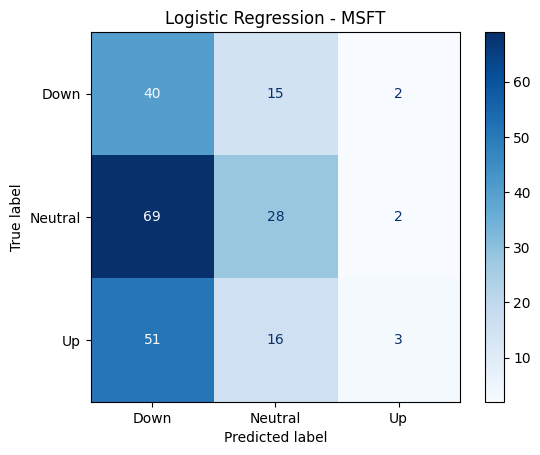


Classification Report
              precision    recall  f1-score   support

        Down       0.25      0.70      0.37        57
     Neutral       0.47      0.28      0.35        99
          Up       0.43      0.04      0.08        70

    accuracy                           0.31       226
   macro avg       0.38      0.34      0.27       226
weighted avg       0.40      0.31      0.27       226



In [31]:
# ==========================================================
# Logistic Regression
# ==========================================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr_model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_model.fit(x_train_scaled, y_train)

lr_pred = lr_model.predict(x_test_scaled)
lr_prob = lr_model.predict_proba(x_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_balanced_accuracy = balanced_accuracy_score(y_test, lr_pred)
lr_precision = precision_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)
lr_recall = recall_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)
lr_f1 = f1_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)
lr_roc_auc = roc_auc_score(
    y_test,
    lr_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"Logistic Regression - {stock}")
print("=" * 60)

print(f"Accuracy            : {lr_accuracy:.4f}")
print(f"Balanced Accuracy   : {lr_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {lr_precision:.4f}")
print(f"Recall (Weighted)   : {lr_recall:.4f}")
print(f"F1 Score (Weighted) : {lr_f1:.4f}")
print(f"ROC-AUC (OvR)       : {lr_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"Logistic Regression - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        lr_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "Logistic Regression",
    "accuracy": lr_accuracy,
    "balanced_accuracy": lr_balanced_accuracy,
    "precision_weighted": lr_precision,
    "recall_weighted": lr_recall,
    "f1_weighted": lr_f1,
    "roc_auc_ovr": lr_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "Logistic Regression",
        "actual": y_test.values,
        "predicted": lr_pred,
        "prob_down": lr_prob[:, 0],
        "prob_neutral": lr_prob[:, 1],
        "prob_up": lr_prob[:, 2]
    })
)


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Training sequence shape: (1218, 30, 34)
Testing sequence shape : (226, 30, 34)
Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3014 - loss: 1.1510 - val_accuracy: 0.2732 - val_loss: 1.1709
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4560 - loss: 1.0622 - val_accuracy: 0.3060 - val_loss: 1.1701
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4589 - loss: 1.0500 - val_accuracy: 0.2896 - val_loss: 1.1764
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4841 - loss: 1.0310 - val_accuracy: 0.2951 - val_loss: 1.1686
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4918 - loss: 1.0150 - val_accuracy: 0.2951 - val_loss: 1.1393
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5082 - loss: 0.9944 - val_accuracy: 0.2951 - val_loss: 1.2118
Epoch 7/50
33/3

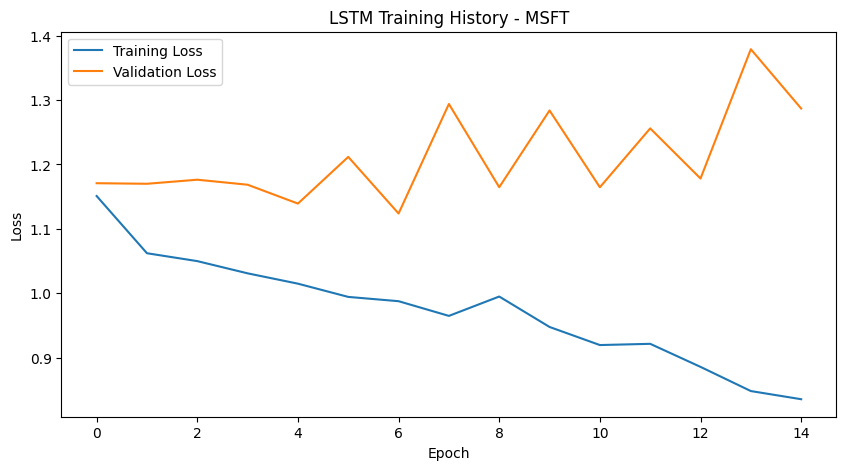

LSTM - MSFT
Accuracy            : 0.4071
Balanced Accuracy   : 0.3353
Precision (Weighted): 0.3393
Recall (Weighted)   : 0.4071
F1 Score (Weighted) : 0.3490
ROC-AUC (OvR)       : 0.4887


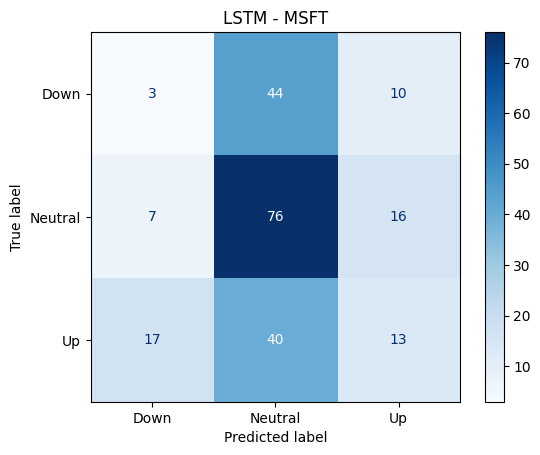


Classification Report
              precision    recall  f1-score   support

        Down       0.11      0.05      0.07        57
     Neutral       0.47      0.77      0.59        99
          Up       0.33      0.19      0.24        70

    accuracy                           0.41       226
   macro avg       0.31      0.34      0.30       226
weighted avg       0.34      0.41      0.35       226



In [32]:
# ==========================================================
# LSTM
# ==========================================================

import tensorflow as tf

tf.keras.utils.set_random_seed(RANDOM_STATE)

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("GPU available:", tf.config.list_physical_devices("GPU"))

# ----------------------------------------------------------
# Scale data using training data only
# ----------------------------------------------------------

lstm_scaler = StandardScaler()

x_train_lstm_scaled = lstm_scaler.fit_transform(x_train)
x_test_lstm_scaled = lstm_scaler.transform(x_test)

x_train_lstm_scaled = pd.DataFrame(
    x_train_lstm_scaled,
    columns=x_train.columns
)

x_test_lstm_scaled = pd.DataFrame(
    x_test_lstm_scaled,
    columns=x_test.columns
)

# ----------------------------------------------------------
# Create sequences
# ----------------------------------------------------------

lookback = 30

x_train_seq = []
y_train_seq = []

for i in range(lookback, len(x_train_lstm_scaled)):

    x_train_seq.append(
        x_train_lstm_scaled.iloc[i-lookback:i].values
    )

    y_train_seq.append(
        y_train.iloc[i]
    )

# Use the final training observations as context for 2025
x_test_context = pd.concat([
    x_train_lstm_scaled.tail(lookback),
    x_test_lstm_scaled
], ignore_index=True)

x_test_seq = []
y_test_seq = []

for i in range(lookback, len(x_test_context)):

    x_test_seq.append(
        x_test_context.iloc[i-lookback:i].values
    )

    y_test_seq.append(
        y_test.iloc[i-lookback]
    )

x_train_seq = np.array(x_train_seq)
y_train_seq = np.array(y_train_seq)

x_test_seq = np.array(x_test_seq)
y_test_seq = np.array(y_test_seq)

print("Training sequence shape:", x_train_seq.shape)
print("Testing sequence shape :", x_test_seq.shape)

# ----------------------------------------------------------
# Build LSTM
# ----------------------------------------------------------

lstm_model = Sequential([
    Input(
        shape=(
            x_train_seq.shape[1],
            x_train_seq.shape[2]
        )
    ),

    LSTM(64),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(3, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ----------------------------------------------------------
# Train LSTM
# ----------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    x_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

# ----------------------------------------------------------
# Training history
# ----------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"LSTM Training History - {stock}")
plt.legend()
plt.show()

# ----------------------------------------------------------
# Evaluate LSTM
# ----------------------------------------------------------

lstm_prob = lstm_model.predict(
    x_test_seq,
    verbose=0
)

lstm_pred = np.argmax(
    lstm_prob,
    axis=1
)

lstm_accuracy = accuracy_score(
    y_test_seq,
    lstm_pred
)

lstm_balanced_accuracy = balanced_accuracy_score(
    y_test_seq,
    lstm_pred
)

lstm_precision = precision_score(
    y_test_seq,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_recall = recall_score(
    y_test_seq,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_f1 = f1_score(
    y_test_seq,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_roc_auc = roc_auc_score(
    y_test_seq,
    lstm_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"LSTM - {stock}")
print("=" * 60)

print(f"Accuracy            : {lstm_accuracy:.4f}")
print(f"Balanced Accuracy   : {lstm_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {lstm_precision:.4f}")
print(f"Recall (Weighted)   : {lstm_recall:.4f}")
print(f"F1 Score (Weighted) : {lstm_f1:.4f}")
print(f"ROC-AUC (OvR)       : {lstm_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test_seq,
    lstm_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"LSTM - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test_seq,
        lstm_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "LSTM",
    "accuracy": lstm_accuracy,
    "balanced_accuracy": lstm_balanced_accuracy,
    "precision_weighted": lstm_precision,
    "recall_weighted": lstm_recall,
    "f1_weighted": lstm_f1,
    "roc_auc_ovr": lstm_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "LSTM",
        "actual": y_test_seq,
        "predicted": lstm_pred,
        "prob_down": lstm_prob[:, 0],
        "prob_neutral": lstm_prob[:, 1],
        "prob_up": lstm_prob[:, 2]
    })
)


## NVDA — Stock-Specific Baseline Models

The five models below are trained and evaluated using only this stock's data.

Run these cells in order for the selected stock. Results are appended to the shared `all_results` and `all_predictions` containers.


In [33]:
# ==========================================================
# Select Stock
# ==========================================================

stock = "NVDA"

x_train = stock_data[stock]["x_train"]
y_train = stock_data[stock]["y_train"]

x_test = stock_data[stock]["x_test"]
y_test = stock_data[stock]["y_test"]

test_dates = stock_data[stock]["test_dates"]

print("=" * 60)
print(f"Selected Stock: {stock}")
print("=" * 60)

print(f"Training samples  : {len(x_train)}")
print(f"Testing samples   : {len(x_test)}")
print(f"Number of features: {x_train.shape[1]}")


Selected Stock: NVDA
Training samples  : 1248
Testing samples   : 226
Number of features: 34


## Model 1 — Dummy Classifier

The Dummy Classifier provides a simple majority-class baseline. It is not expected to learn relationships between the predictors and the target.

## Model 2 — Random Forest

Random Forest provides a non-linear tree-based baseline. The model uses the original feature scale because tree-based models do not require standardization.

## Model 3 — XGBoost

XGBoost provides a second non-linear tree-based baseline. It also uses the original feature scale.

## Model 4 — Logistic Regression

Logistic Regression is intentionally placed after the tree-based models because its input features must be standardized.

The scaler is fitted only on the training data and then applied to the test data.

## Model 5 — LSTM

LSTM is included as a sequence-based deep-learning baseline.

A **30-trading-day lookback** is used. The scaler is fitted only on the training data. The last 30 scaled training observations are used as historical context for the first 2025 test sequence.

> **GPU note:** GPU acceleration is optional for this relatively small LSTM. If GPU is enabled in Kaggle, training can use it automatically. The model is small enough to run on CPU as well.

> **Reproducibility note:** TensorFlow random seeds are explicitly controlled. Neural-network training can still show small backend/hardware-dependent differences, so LSTM results should be interpreted with appropriate caution.

Dummy Classifier - NVDA
Accuracy            : 0.4558
Balanced Accuracy   : 0.3333
Precision (Weighted): 0.2077
Recall (Weighted)   : 0.4558
F1 Score (Weighted) : 0.2854
ROC-AUC (OvR)       : 0.5000


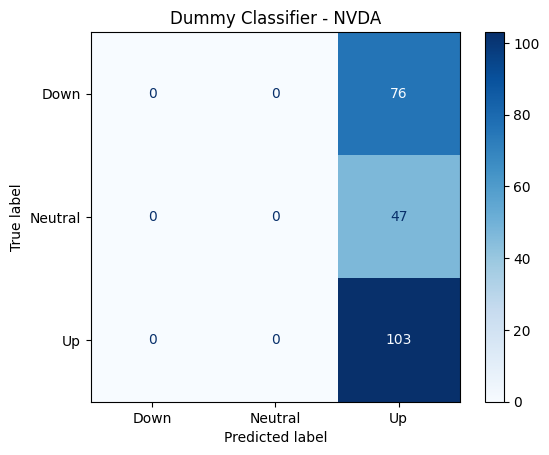


Classification Report
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00        76
     Neutral       0.00      0.00      0.00        47
          Up       0.46      1.00      0.63       103

    accuracy                           0.46       226
   macro avg       0.15      0.33      0.21       226
weighted avg       0.21      0.46      0.29       226



In [34]:
# ==========================================================
# Dummy Classifier
# ==========================================================

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(x_train, y_train)

dummy_pred = dummy_model.predict(x_test)
dummy_prob = dummy_model.predict_proba(x_test)

dummy_accuracy = accuracy_score(y_test, dummy_pred)
dummy_balanced_accuracy = balanced_accuracy_score(y_test, dummy_pred)
dummy_precision = precision_score(
    y_test, dummy_pred,
    average="weighted",
    zero_division=0
)
dummy_recall = recall_score(
    y_test, dummy_pred,
    average="weighted",
    zero_division=0
)
dummy_f1 = f1_score(
    y_test, dummy_pred,
    average="weighted",
    zero_division=0
)
dummy_roc_auc = roc_auc_score(
    y_test,
    dummy_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"Dummy Classifier - {stock}")
print("=" * 60)

print(f"Accuracy            : {dummy_accuracy:.4f}")
print(f"Balanced Accuracy   : {dummy_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {dummy_precision:.4f}")
print(f"Recall (Weighted)   : {dummy_recall:.4f}")
print(f"F1 Score (Weighted) : {dummy_f1:.4f}")
print(f"ROC-AUC (OvR)       : {dummy_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dummy_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"Dummy Classifier - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        dummy_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "Dummy",
    "accuracy": dummy_accuracy,
    "balanced_accuracy": dummy_balanced_accuracy,
    "precision_weighted": dummy_precision,
    "recall_weighted": dummy_recall,
    "f1_weighted": dummy_f1,
    "roc_auc_ovr": dummy_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "Dummy",
        "actual": y_test.values,
        "predicted": dummy_pred,
        "prob_down": dummy_prob[:, 0],
        "prob_neutral": dummy_prob[:, 1],
        "prob_up": dummy_prob[:, 2]
    })
)


Random Forest - NVDA
Accuracy            : 0.4071
Balanced Accuracy   : 0.3414
Precision (Weighted): 0.3428
Recall (Weighted)   : 0.4071
F1 Score (Weighted) : 0.3674
ROC-AUC (OvR)       : 0.5819


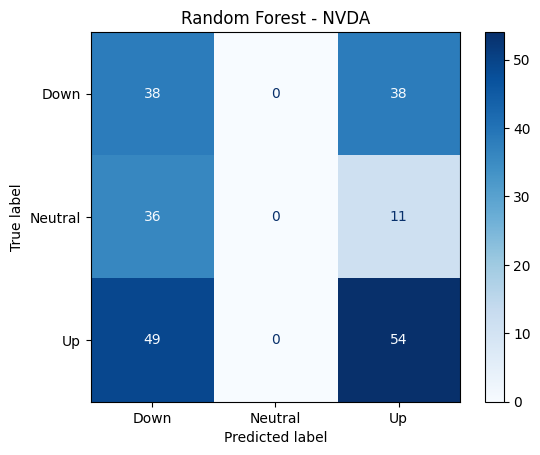


Classification Report
              precision    recall  f1-score   support

        Down       0.31      0.50      0.38        76
     Neutral       0.00      0.00      0.00        47
          Up       0.52      0.52      0.52       103

    accuracy                           0.41       226
   macro avg       0.28      0.34      0.30       226
weighted avg       0.34      0.41      0.37       226



In [35]:
# ==========================================================
# Random Forest
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
rf_prob = rf_model.predict_proba(x_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_balanced_accuracy = balanced_accuracy_score(y_test, rf_pred)
rf_precision = precision_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)
rf_recall = recall_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)
rf_f1 = f1_score(
    y_test, rf_pred,
    average="weighted",
    zero_division=0
)
rf_roc_auc = roc_auc_score(
    y_test,
    rf_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"Random Forest - {stock}")
print("=" * 60)

print(f"Accuracy            : {rf_accuracy:.4f}")
print(f"Balanced Accuracy   : {rf_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {rf_precision:.4f}")
print(f"Recall (Weighted)   : {rf_recall:.4f}")
print(f"F1 Score (Weighted) : {rf_f1:.4f}")
print(f"ROC-AUC (OvR)       : {rf_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"Random Forest - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        rf_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "Random Forest",
    "accuracy": rf_accuracy,
    "balanced_accuracy": rf_balanced_accuracy,
    "precision_weighted": rf_precision,
    "recall_weighted": rf_recall,
    "f1_weighted": rf_f1,
    "roc_auc_ovr": rf_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "Random Forest",
        "actual": y_test.values,
        "predicted": rf_pred,
        "prob_down": rf_prob[:, 0],
        "prob_neutral": rf_prob[:, 1],
        "prob_up": rf_prob[:, 2]
    })
)


XGBoost - NVDA
Accuracy            : 0.3982
Balanced Accuracy   : 0.3415
Precision (Weighted): 0.3873
Recall (Weighted)   : 0.3982
F1 Score (Weighted) : 0.3815
ROC-AUC (OvR)       : 0.5691


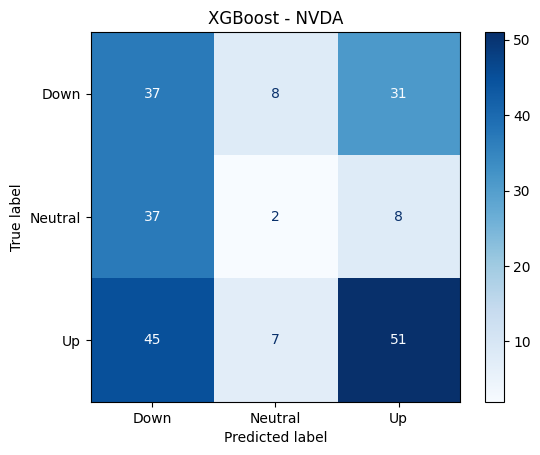


Classification Report
              precision    recall  f1-score   support

        Down       0.31      0.49      0.38        76
     Neutral       0.12      0.04      0.06        47
          Up       0.57      0.50      0.53       103

    accuracy                           0.40       226
   macro avg       0.33      0.34      0.32       226
weighted avg       0.39      0.40      0.38       226



In [36]:
# ==========================================================
# XGBoost
# ==========================================================

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=RANDOM_STATE,
    eval_metric="mlogloss"
)

xgb_model.fit(x_train, y_train)

xgb_pred = xgb_model.predict(x_test)
xgb_prob = xgb_model.predict_proba(x_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_balanced_accuracy = balanced_accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(
    y_test, xgb_pred,
    average="weighted",
    zero_division=0
)
xgb_recall = recall_score(
    y_test, xgb_pred,
    average="weighted",
    zero_division=0
)
xgb_f1 = f1_score(
    y_test, xgb_pred,
    average="weighted",
    zero_division=0
)
xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"XGBoost - {stock}")
print("=" * 60)

print(f"Accuracy            : {xgb_accuracy:.4f}")
print(f"Balanced Accuracy   : {xgb_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {xgb_precision:.4f}")
print(f"Recall (Weighted)   : {xgb_recall:.4f}")
print(f"F1 Score (Weighted) : {xgb_f1:.4f}")
print(f"ROC-AUC (OvR)       : {xgb_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"XGBoost - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        xgb_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "XGBoost",
    "accuracy": xgb_accuracy,
    "balanced_accuracy": xgb_balanced_accuracy,
    "precision_weighted": xgb_precision,
    "recall_weighted": xgb_recall,
    "f1_weighted": xgb_f1,
    "roc_auc_ovr": xgb_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "XGBoost",
        "actual": y_test.values,
        "predicted": xgb_pred,
        "prob_down": xgb_prob[:, 0],
        "prob_neutral": xgb_prob[:, 1],
        "prob_up": xgb_prob[:, 2]
    })
)


Logistic Regression - NVDA
Accuracy            : 0.3717
Balanced Accuracy   : 0.2833
Precision (Weighted): 0.2596
Recall (Weighted)   : 0.3717
F1 Score (Weighted) : 0.2989
ROC-AUC (OvR)       : 0.4727


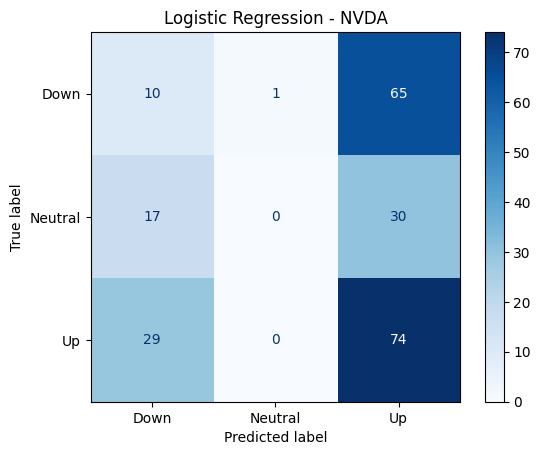


Classification Report
              precision    recall  f1-score   support

        Down       0.18      0.13      0.15        76
     Neutral       0.00      0.00      0.00        47
          Up       0.44      0.72      0.54       103

    accuracy                           0.37       226
   macro avg       0.21      0.28      0.23       226
weighted avg       0.26      0.37      0.30       226



In [37]:
# ==========================================================
# Logistic Regression
# ==========================================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr_model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_model.fit(x_train_scaled, y_train)

lr_pred = lr_model.predict(x_test_scaled)
lr_prob = lr_model.predict_proba(x_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_balanced_accuracy = balanced_accuracy_score(y_test, lr_pred)
lr_precision = precision_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)
lr_recall = recall_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)
lr_f1 = f1_score(
    y_test, lr_pred,
    average="weighted",
    zero_division=0
)
lr_roc_auc = roc_auc_score(
    y_test,
    lr_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"Logistic Regression - {stock}")
print("=" * 60)

print(f"Accuracy            : {lr_accuracy:.4f}")
print(f"Balanced Accuracy   : {lr_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {lr_precision:.4f}")
print(f"Recall (Weighted)   : {lr_recall:.4f}")
print(f"F1 Score (Weighted) : {lr_f1:.4f}")
print(f"ROC-AUC (OvR)       : {lr_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"Logistic Regression - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test,
        lr_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "Logistic Regression",
    "accuracy": lr_accuracy,
    "balanced_accuracy": lr_balanced_accuracy,
    "precision_weighted": lr_precision,
    "recall_weighted": lr_recall,
    "f1_weighted": lr_f1,
    "roc_auc_ovr": lr_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "Logistic Regression",
        "actual": y_test.values,
        "predicted": lr_pred,
        "prob_down": lr_prob[:, 0],
        "prob_neutral": lr_prob[:, 1],
        "prob_up": lr_prob[:, 2]
    })
)


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Training sequence shape: (1218, 30, 34)
Testing sequence shape : (226, 30, 34)
Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3990 - loss: 1.0772 - val_accuracy: 0.3552 - val_loss: 1.0695
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5420 - loss: 1.0150 - val_accuracy: 0.5027 - val_loss: 0.9767
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5614 - loss: 0.9771 - val_accuracy: 0.5738 - val_loss: 0.9580
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5556 - loss: 0.9670 - val_accuracy: 0.5464 - val_loss: 0.9548
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5652 - loss: 0.9418 - val_accuracy: 0.5628 - val_loss: 0.9494
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5700 - loss: 0.9525 - val_accuracy: 0.5355 - val_loss: 0.9676
Epoch 7/50
33/33

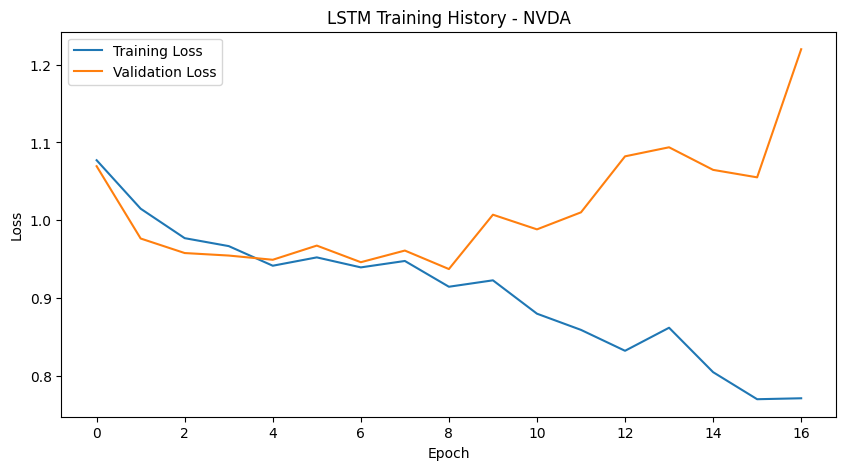

LSTM - NVDA
Accuracy            : 0.3540
Balanced Accuracy   : 0.2715
Precision (Weighted): 0.2526
Recall (Weighted)   : 0.3540
F1 Score (Weighted) : 0.2912
ROC-AUC (OvR)       : 0.5195


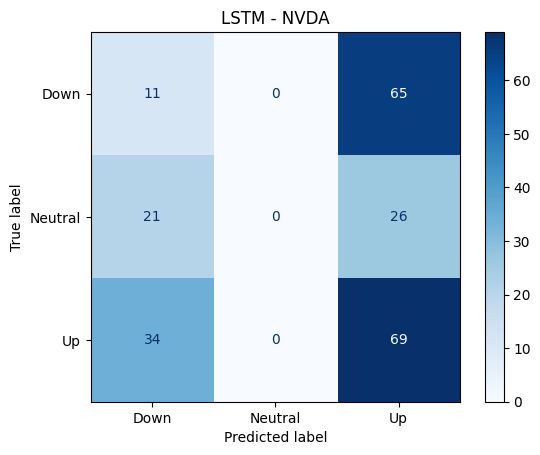


Classification Report
              precision    recall  f1-score   support

        Down       0.17      0.14      0.15        76
     Neutral       0.00      0.00      0.00        47
          Up       0.43      0.67      0.52       103

    accuracy                           0.35       226
   macro avg       0.20      0.27      0.23       226
weighted avg       0.25      0.35      0.29       226



In [38]:
# ==========================================================
# LSTM
# ==========================================================

import tensorflow as tf

tf.keras.utils.set_random_seed(RANDOM_STATE)

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("GPU available:", tf.config.list_physical_devices("GPU"))

# ----------------------------------------------------------
# Scale data using training data only
# ----------------------------------------------------------

lstm_scaler = StandardScaler()

x_train_lstm_scaled = lstm_scaler.fit_transform(x_train)
x_test_lstm_scaled = lstm_scaler.transform(x_test)

x_train_lstm_scaled = pd.DataFrame(
    x_train_lstm_scaled,
    columns=x_train.columns
)

x_test_lstm_scaled = pd.DataFrame(
    x_test_lstm_scaled,
    columns=x_test.columns
)

# ----------------------------------------------------------
# Create sequences
# ----------------------------------------------------------

lookback = 30

x_train_seq = []
y_train_seq = []

for i in range(lookback, len(x_train_lstm_scaled)):

    x_train_seq.append(
        x_train_lstm_scaled.iloc[i-lookback:i].values
    )

    y_train_seq.append(
        y_train.iloc[i]
    )

# Use the final training observations as context for 2025
x_test_context = pd.concat([
    x_train_lstm_scaled.tail(lookback),
    x_test_lstm_scaled
], ignore_index=True)

x_test_seq = []
y_test_seq = []

for i in range(lookback, len(x_test_context)):

    x_test_seq.append(
        x_test_context.iloc[i-lookback:i].values
    )

    y_test_seq.append(
        y_test.iloc[i-lookback]
    )

x_train_seq = np.array(x_train_seq)
y_train_seq = np.array(y_train_seq)

x_test_seq = np.array(x_test_seq)
y_test_seq = np.array(y_test_seq)

print("Training sequence shape:", x_train_seq.shape)
print("Testing sequence shape :", x_test_seq.shape)

# ----------------------------------------------------------
# Build LSTM
# ----------------------------------------------------------

lstm_model = Sequential([
    Input(
        shape=(
            x_train_seq.shape[1],
            x_train_seq.shape[2]
        )
    ),

    LSTM(64),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(3, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ----------------------------------------------------------
# Train LSTM
# ----------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    x_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

# ----------------------------------------------------------
# Training history
# ----------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"LSTM Training History - {stock}")
plt.legend()
plt.show()

# ----------------------------------------------------------
# Evaluate LSTM
# ----------------------------------------------------------

lstm_prob = lstm_model.predict(
    x_test_seq,
    verbose=0
)

lstm_pred = np.argmax(
    lstm_prob,
    axis=1
)

lstm_accuracy = accuracy_score(
    y_test_seq,
    lstm_pred
)

lstm_balanced_accuracy = balanced_accuracy_score(
    y_test_seq,
    lstm_pred
)

lstm_precision = precision_score(
    y_test_seq,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_recall = recall_score(
    y_test_seq,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_f1 = f1_score(
    y_test_seq,
    lstm_pred,
    average="weighted",
    zero_division=0
)

lstm_roc_auc = roc_auc_score(
    y_test_seq,
    lstm_prob,
    multi_class="ovr"
)

print("=" * 60)
print(f"LSTM - {stock}")
print("=" * 60)

print(f"Accuracy            : {lstm_accuracy:.4f}")
print(f"Balanced Accuracy   : {lstm_balanced_accuracy:.4f}")
print(f"Precision (Weighted): {lstm_precision:.4f}")
print(f"Recall (Weighted)   : {lstm_recall:.4f}")
print(f"F1 Score (Weighted) : {lstm_f1:.4f}")
print(f"ROC-AUC (OvR)       : {lstm_roc_auc:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test_seq,
    lstm_pred,
    display_labels=["Down", "Neutral", "Up"],
    cmap="Blues"
)

plt.title(f"LSTM - {stock}")
plt.show()

print("\nClassification Report")
print(
    classification_report(
        y_test_seq,
        lstm_pred,
        labels=[0, 1, 2],
        target_names=["Down", "Neutral", "Up"],
        zero_division=0
    )
)

all_results.append({
    "ticker": stock,
    "model": "LSTM",
    "accuracy": lstm_accuracy,
    "balanced_accuracy": lstm_balanced_accuracy,
    "precision_weighted": lstm_precision,
    "recall_weighted": lstm_recall,
    "f1_weighted": lstm_f1,
    "roc_auc_ovr": lstm_roc_auc
})

all_predictions.append(
    pd.DataFrame({
        "ticker": stock,
        "date": test_dates,
        "model": "LSTM",
        "actual": y_test_seq,
        "predicted": lstm_pred,
        "prob_down": lstm_prob[:, 0],
        "prob_neutral": lstm_prob[:, 1],
        "prob_up": lstm_prob[:, 2]
    })
)


## Final Five-Stock Model Comparison

After all five stock blocks have been run, the following cells summarize all 25 model evaluations.

The primary comparison metric is **Balanced Accuracy**, while Accuracy, weighted F1, and multiclass ROC-AUC are retained for additional interpretation.


In [39]:
# ==========================================================
# Final Performance Results
# ==========================================================

results_df = pd.DataFrame(all_results)

print(f"Number of model evaluations: {len(results_df)}")

if len(results_df) != 25:
    print(
        "\nNote: Notebook 08 expects 25 evaluations "
        "(5 stocks × 5 models)."
    )
    print("Finish the remaining stocks before treating this as the final comparison.")

display(
    results_df.sort_values(
        ["ticker", "balanced_accuracy"],
        ascending=[True, False]
    ).reset_index(drop=True)
)


Number of model evaluations: 25


,ticker,model,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr
0,BRK-B,XGBoost,0.3894,0.4376,0.5156,0.3894,0.3666,0.5962
1,BRK-B,Logistic Regression,0.3363,0.4080,0.4815,0.3363,0.2700,0.5393
2,BRK-B,Random Forest,0.3053,0.3756,0.4727,0.3053,0.2529,0.5602
3,BRK-B,Dummy,0.5044,0.3333,0.2544,0.5044,0.3383,0.5000
4,BRK-B,LSTM,0.4779,0.3229,0.3080,0.4779,0.3484,0.5466
5,CVX,LSTM,0.4071,0.3705,0.3324,0.4071,0.3285,0.5444
6,CVX,Random Forest,0.3363,0.3623,0.4795,0.3363,0.3383,0.5633
7,CVX,XGBoost,0.2920,0.3579,0.3628,0.2920,0.2665,0.5310
8,CVX,Logistic Regression,0.3761,0.3397,0.3203,0.3761,0.3109,0.5485
9,CVX,Dummy,0.3451,0.3333,0.1191,0.3451,0.1771,0.5000


In [40]:
# ==========================================================
# Highlight Best Model for Each Stock
# ==========================================================

def highlight_best(row):

    best_value = (
        results_df[
            results_df["ticker"] == row["ticker"]
        ]["balanced_accuracy"].max()
    )

    if row["balanced_accuracy"] == best_value:
        return ["background-color: lightgreen"] * len(row)

    return [""] * len(row)


display(
    results_df
    .sort_values(
        ["ticker", "balanced_accuracy"],
        ascending=[True, False]
    )
    .style
    .apply(highlight_best, axis=1)
    .format({
        "accuracy": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "precision_weighted": "{:.4f}",
        "recall_weighted": "{:.4f}",
        "f1_weighted": "{:.4f}",
        "roc_auc_ovr": "{:.4f}"
    })
)


,ticker,model,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr
2,BRK-B,XGBoost,0.3894,0.4376,0.5156,0.3894,0.3666,0.5962
3,BRK-B,Logistic Regression,0.3363,0.4080,0.4815,0.3363,0.2700,0.5393
1,BRK-B,Random Forest,0.3053,0.3756,0.4727,0.3053,0.2529,0.5602
0,BRK-B,Dummy,0.5044,0.3333,0.2544,0.5044,0.3383,0.5000
4,BRK-B,LSTM,0.4779,0.3229,0.3080,0.4779,0.3484,0.5466
9,CVX,LSTM,0.4071,0.3705,0.3324,0.4071,0.3285,0.5444
6,CVX,Random Forest,0.3363,0.3623,0.4795,0.3363,0.3383,0.5633
7,CVX,XGBoost,0.2920,0.3579,0.3628,0.2920,0.2665,0.5310
8,CVX,Logistic Regression,0.3761,0.3397,0.3203,0.3761,0.3109,0.5485
5,CVX,Dummy,0.3451,0.3333,0.1191,0.3451,0.1771,0.5000


In [41]:
# ==========================================================
# Best Model per Stock
# ==========================================================

best_per_stock = (
    results_df
    .sort_values(
        ["ticker", "balanced_accuracy"],
        ascending=[True, False]
    )
    .groupby("ticker", as_index=False)
    .first()
)

display(
    best_per_stock[
        [
            "ticker",
            "model",
            "accuracy",
            "balanced_accuracy",
            "f1_weighted",
            "roc_auc_ovr"
        ]
    ]
)


,ticker,model,accuracy,balanced_accuracy,f1_weighted,roc_auc_ovr
0,BRK-B,XGBoost,0.3894,0.4376,0.3666,0.5962
1,CVX,LSTM,0.4071,0.3705,0.3285,0.5444
2,GE,XGBoost,0.3894,0.4482,0.3764,0.5828
3,MSFT,Logistic Regression,0.3142,0.3425,0.2724,0.4715
4,NVDA,XGBoost,0.3982,0.3415,0.3815,0.5691


In [42]:
# ==========================================================
# Save Model Performance Results
# ==========================================================

results_df.to_csv(
    "/kaggle/working/baseline_model_performance.csv",
    index=False
)

print("Saved: /kaggle/working/baseline_model_performance.csv")


Saved: /kaggle/working/baseline_model_performance.csv


In [43]:
# ==========================================================
# Save Test Predictions and Probabilities
# ==========================================================

predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)

predictions_df.to_csv(
    "/kaggle/working/baseline_predictions.csv",
    index=False
)

print(f"Prediction rows: {len(predictions_df):,}")
print("Saved: /kaggle/working/baseline_predictions.csv")

display(predictions_df.head())


Prediction rows: 5,650
Saved: /kaggle/working/baseline_predictions.csv


,ticker,date,model,actual,predicted,prob_down,prob_neutral,prob_up
0,BRK-B,2025-01-02,Dummy,0,1,0.0000,1.0000,0.0000
1,BRK-B,2025-01-03,Dummy,0,1,0.0000,1.0000,0.0000
2,BRK-B,2025-01-06,Dummy,1,1,0.0000,1.0000,0.0000
3,BRK-B,2025-01-07,Dummy,1,1,0.0000,1.0000,0.0000
4,BRK-B,2025-01-08,Dummy,2,1,0.0000,1.0000,0.0000
